# Batool Thesis — Journal of Medical Systems: Revised Technical-Ready Notebook

**Study framing:** reliability- and subgroup-safety audit of a non-invasive lifestyle/demographic
diabetes risk-triage decision-support model using CDC/BRFSS health indicator data.

---

### Audit fixes applied in this revision

| ID | Issue | Fix applied |
|----|-------|-------------|
| C1 | External validation claim | Correct label applied throughout: "temporal validation on a same-source survey cohort" |
| C2 | Calibration collapse at natural prevalence | Explicit prevalence-adjusted recalibration discussion; ECE reported for every evaluation set |
| C3 | 18–34 subgroup underpowered | Subgroup n + positive count reported; CIs added for subgroup AUC; 18–34 collapsed with 35–44 for claims |
| M1 | No statistical test for model comparison | Wilcoxon signed-rank test across CV folds added |
| M2 | UMAP/t-SNE error map missing | UMAP error-space projection added (RQ6) |
| M3 | Permutation vs SHAP discrepancy unexplained | Correlation analysis and narrative explanation added |
| M4 | Duplicate profiles unacknowledged | Reported in sanity table and as a limitation in interpretation notes |
| A1 | Scorecard framing | Explicit "author-defined research framework" disclaimer |
| A2 | Threshold rationale | Clinical framing for all three thresholds; screening threshold highlighted as primary recommendation |
| A3 | Prediabetes handling in external set | Rows-dropped count reported explicitly |
| A4 | Underweight subgroup too small | Flagged as unreliable; pooled with Normal weight for claims |
| JMS-1 | TRIPOD+AI checklist | Saved as supplementary CSV |
| JMS-2 | Study scope framing | Decision-support / health-informatics language throughout |
| JMS-3 | Code + data availability | Notes added to manifest |

**Dataset requirements (Kaggle)**
- `diabetes_binary_5050split_health_indicators_BRFSS2015.csv` — balanced development set
- `diabetes_binary_health_indicators_BRFSS2015.csv` — natural-prevalence prevalence-shift validation
- Optional: BRFSS 2021 file for temporal validation (set `EXTERNAL_DATA_PATH` manually)

In [1]:
# ============================================================
# 0. Configuration
# ============================================================
import os, re, json, math, glob, shutil, warnings
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")

RANDOM_STATE        = 42
N_SPLITS_CV         = 5
N_BOOTSTRAPS        = 500       # use 1000+ for final submission if runtime allows
TEST_SIZE           = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.20
TARGET_RECALL       = 0.80
STABILITY_SEEDS     = [11, 42, 77, 101, 202]
SHAP_SAMPLE_SIZE    = 1000
PERMUTATION_SAMPLE_SIZE = 5000
UMAP_SAMPLE_SIZE    = 3000      # rows fed to UMAP for error-space projection (RQ6)

# Exact filenames — prevents silent path confusion
PRIMARY_FILENAME = "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
NATURAL_FILENAME = "diabetes_binary_health_indicators_BRFSS2015.csv"

# Manual override paths: set only if auto-detection fails on your platform
PRIMARY_DATA_PATH          = None
NATURAL_PREVALENCE_DATA_PATH = None
EXTERNAL_DATA_PATH         = None   # path to BRFSS 2021 CSV if available

# How to handle Diabetes_012 prediabetes category in external datasets
# "exclude" = drop prediabetes rows; "non_diabetes" = treat as 0; "diabetes_risk" = treat as 1
PREDIABETES_HANDLING = "exclude"

LIFESTYLE_FEATURES   = ["BMI", "Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump"]
DEMOGRAPHIC_FEATURES = ["Sex", "Age", "Education", "Income"]
SELECTED_FEATURES    = LIFESTYLE_FEATURES + DEMOGRAPHIC_FEATURES

OUTPUT_ROOT = (
    Path("/kaggle/working/batool_jms_revised_outputs")
    if Path("/kaggle/working").exists()
    else Path("./batool_jms_revised_outputs")
)
TABLE_DIR  = OUTPUT_ROOT / "tables"
FIGURE_DIR = OUTPUT_ROOT / "figures"
MODEL_DIR  = OUTPUT_ROOT / "models"
for d in [OUTPUT_ROOT, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output root:", OUTPUT_ROOT.resolve())

Output root: /kaggle/working/batool_jms_revised_outputs


In [2]:
# ============================================================
# 1. Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker

from IPython.display import display

from scipy import stats as scipy_stats
from scipy.special import logit

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    brier_score_loss, precision_recall_curve, roc_curve, auc
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier
)

try:
    import joblib
except Exception:
    joblib = None

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False
    print("SHAP not installed; permutation importance will be the primary interpretability output.")

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    print("XGBoost not installed; best model will fall back to Gradient Boosting.")

try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False
    print("umap-learn not installed; UMAP projection will be skipped.")

print(f"SHAP={SHAP_AVAILABLE}  XGBoost={XGB_AVAILABLE}  UMAP={UMAP_AVAILABLE}")

# ─── Publication-quality plot style ──────────────────────────────────────────
matplotlib.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
    "grid.color": "#cccccc",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.framealpha": 0.85,
    "legend.edgecolor": "#dddddd",
    "lines.linewidth": 1.8,
    "patch.linewidth": 0.8,
})

# Accessible colour palette (Okabe-Ito + extensions)
C = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "red":    "#D55E00",
    "purple": "#CC79A7",
    "sky":    "#56B4E9",
    "yellow": "#F0E442",
    "black":  "#222222",
    "gray":   "#888888",
    "lgray":  "#dddddd",
}

2026-06-05 17:09:16.573355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780679356.807107      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780679356.876477      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780679357.434018      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780679357.434077      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780679357.434080      58 computation_placer.cc:177] computation placer alr

SHAP=True  XGBoost=True  UMAP=True


In [3]:
# ============================================================
# 2. Dataset discovery with hard safety guards
# ============================================================
def list_csvs(root="/kaggle/input"):
    if Path(root).exists():
        return sorted(glob.glob(str(Path(root) / "**" / "*.csv"), recursive=True))
    return sorted(glob.glob("**/*.csv", recursive=True))

ALL_CSVS = list_csvs()
print("Detected CSV files:")
for p in ALL_CSVS:
    print(" -", p)
if not ALL_CSVS:
    print("No CSVs found. On Kaggle, attach the required dataset from the input panel.")


def resolve_exact(manual_path, exact_filename, required=True):
    if manual_path is not None:
        p = Path(manual_path)
        if not p.exists():
            raise FileNotFoundError(f"Manual path not found: {manual_path}")
        if p.name != exact_filename:
            raise ValueError(f"Manual path {manual_path} is not {exact_filename}")
        return str(p)
    matches = [p for p in ALL_CSVS if Path(p).name == exact_filename]
    if len(matches) >= 1:
        if len(matches) > 1:
            print(f"Multiple matches for {exact_filename}; using first:", matches[0])
        return matches[0]
    if required:
        raise FileNotFoundError(f"Required file not found: {exact_filename}")
    return None


def resolve_external(manual_path):
    if manual_path is not None:
        p = Path(manual_path)
        if not p.exists():
            raise FileNotFoundError(f"External path not found: {manual_path}")
        return str(p)
    for p in ALL_CSVS:
        nm = Path(p).name.lower()
        if "2021" in nm and "diabetes" in nm:
            print("Auto-selected external/temporal dataset:", p)
            return p
    return None


primary_path  = resolve_exact(PRIMARY_DATA_PATH, PRIMARY_FILENAME, required=True)
natural_path  = resolve_exact(NATURAL_PREVALENCE_DATA_PATH, NATURAL_FILENAME, required=True)
external_path = resolve_external(EXTERNAL_DATA_PATH)

# Hard identity checks — prevents silent mixing of balanced and natural-prevalence files
if Path(primary_path).resolve() == Path(natural_path).resolve():
    raise ValueError(
        "CRITICAL: primary_path and natural_path point to the same file. "
        "Natural-prevalence validation would be invalid."
    )
if "5050" in Path(natural_path).name.lower():
    raise ValueError(
        "CRITICAL: natural_path contains '5050'. "
        "Use diabetes_binary_health_indicators_BRFSS2015.csv instead."
    )

print("\n=== Resolved dataset paths ===")
print("Primary balanced development :", primary_path)
print("Natural-prevalence 2015      :", natural_path)
print("External / temporal (optional):", external_path)

Detected CSV files:
 - /kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv
 - /kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
 - /kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
 - /kaggle/input/datasets/julnazz/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2021.csv
 - /kaggle/input/datasets/julnazz/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2021.csv
 - /kaggle/input/datasets/julnazz/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2021.csv
Auto-selected external/temporal dataset: /kaggle/input/datasets/julnazz/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2021.csv

=== Resolved dataset paths ===
Primary balanced development : /kaggle/input/datasets/alexteboul/diabet

In [4]:
# ============================================================
# DEBUG: Force list all CSV files to find the right filenames
# ============================================================
import os
print("\n=== SEARCHING FOR CSV FILES ===")
csv_files = []
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith('.csv'):
            full_path = os.path.join(root, f)
            csv_files.append(full_path)
            print(f"FOUND: {full_path}")
            
if not csv_files:
    print("WARNING: No CSV files found in /kaggle/input!")
    print("Did you attach the dataset? Go to Add Data → Search for 'diabetes health indicators'")


=== SEARCHING FOR CSV FILES ===
FOUND: /kaggle/input/datasets/julnazz/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2021.csv
FOUND: /kaggle/input/datasets/julnazz/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2021.csv
FOUND: /kaggle/input/datasets/julnazz/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2021.csv
FOUND: /kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
FOUND: /kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
FOUND: /kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


In [5]:
# ============================================================
# 3. Plot / table helpers
# ============================================================
def save_table(df, filename, show_head=True, n=12):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f"  ✓ table  → {path.name}")
    if show_head:
        display(df.head(n))
    return path


def savefig(filename, fig=None):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format="pdf", bbox_inches="tight")
    print(f"  ✓ figure → {path.name}")
    plt.show()
    plt.close("all")
    return path


def safe_auc(y_true, y_prob):
    return roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan


def add_panel_label(ax, label, x=-0.12, y=1.05, fontsize=13):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=fontsize, fontweight="bold", va="top")

In [6]:
# ============================================================
# CHECK: Verify output directory is writable
# ============================================================
print(f"\nOutput directory: {OUTPUT_ROOT}")
print(f"Directory exists: {OUTPUT_ROOT.exists()}")
try:
    test_file = OUTPUT_ROOT / "test_write.txt"
    test_file.write_text("test")
    print("✓ Can write to output directory")
    test_file.unlink()
except Exception as e:
    print(f"✗ Cannot write to output directory: {e}")


Output directory: /kaggle/working/batool_jms_revised_outputs
Directory exists: True
✓ Can write to output directory


In [7]:
# ============================================================
# 4. Data loading, target normalisation, subgroup columns
# ============================================================

def normalize_target(df, dataset_name="dataset"):
    df = df.copy()
    if "Diabetes_binary" in df.columns:
        y = df["Diabetes_binary"].astype(int)
        target_col = "Diabetes_binary"
    elif "diabetes_binary" in df.columns:
        y = df["diabetes_binary"].astype(int)
        target_col = "diabetes_binary"
    elif "Diabetes_012" in df.columns:
        target_col = "Diabetes_012"
        n_before = len(df)
        if PREDIABETES_HANDLING == "exclude":
            df = df[df[target_col] != 1].copy()
            y = (df[target_col] == 2).astype(int)
            print(f"  Prediabetes rows excluded: {n_before - len(df):,}")
        elif PREDIABETES_HANDLING == "non_diabetes":
            y = (df[target_col] == 2).astype(int)
        elif PREDIABETES_HANDLING == "diabetes_risk":
            y = (df[target_col] >= 1).astype(int)
        else:
            raise ValueError("Invalid PREDIABETES_HANDLING")
    elif "diabetes_012" in df.columns:
        target_col = "diabetes_012"
        n_before = len(df)
        if PREDIABETES_HANDLING == "exclude":
            df = df[df[target_col] != 1].copy()
            y = (df[target_col] == 2).astype(int)
            print(f"  Prediabetes rows excluded (A3 fix): {n_before - len(df):,}")
        elif PREDIABETES_HANDLING == "non_diabetes":
            y = (df[target_col] == 2).astype(int)
        elif PREDIABETES_HANDLING == "diabetes_risk":
            y = (df[target_col] >= 1).astype(int)
        else:
            raise ValueError("Invalid PREDIABETES_HANDLING")
    else:
        raise ValueError(f"No recognised diabetes target column in {dataset_name}.")
    return df.reset_index(drop=True), y.reset_index(drop=True), target_col


def age_group(code):
    try:
        a = int(code)
    except Exception:
        return "Unknown"
    if a <= 3:  return "18–34"
    if a <= 5:  return "35–44"
    if a <= 7:  return "45–54"
    if a <= 9:  return "55–64"
    if a <= 11: return "65–74"
    return "75+"

AGE_ORDER = ["18–34", "35–44", "45–54", "55–64", "65–74", "75+"]
BMI_ORDER = ["Underweight", "Normal weight", "Overweight", "Obese I", "Obese II/III"]

def bmi_cat(bmi):
    try:
        b = float(bmi)
    except Exception:
        return "Unknown"
    if b < 18.5: return "Underweight"
    if b < 25:   return "Normal weight"
    if b < 30:   return "Overweight"
    if b < 35:   return "Obese I"
    return "Obese II/III"

SEX_MAP = {0: "Female", 1: "Male", 0.0: "Female", 1.0: "Male"}


def add_subgroup_columns(df):
    df = df.copy()
    df["AgeGroup"]    = df["Age"].apply(age_group)   if "Age" in df.columns else "Unknown"
    df["BMICategory"] = df["BMI"].apply(bmi_cat)     if "BMI" in df.columns else "Unknown"
    df["SexGroup"]    = df["Sex"].map(SEX_MAP).fillna(df["Sex"].astype(str)) if "Sex" in df.columns else "Unknown"
    return df


def load_dataset(path, dataset_name):
    df_raw = pd.read_csv(path)
    df, y, target_col = normalize_target(df_raw, dataset_name)
    missing_feats = [c for c in SELECTED_FEATURES if c not in df.columns]
    if missing_feats:
        raise ValueError(f"{dataset_name} missing: {missing_feats}")
    X     = df[SELECTED_FEATURES].copy().reset_index(drop=True)
    X_sub = add_subgroup_columns(X)
    y     = y.reset_index(drop=True)
    n_prediabetes_dropped = int(len(df_raw) - len(df)) if "012" in target_col else 0
    summary = {
        "dataset":                               dataset_name,
        "path":                                  str(path),
        "filename":                              Path(path).name,
        "raw_rows":                              int(len(df_raw)),
        "prediabetes_rows_excluded":             n_prediabetes_dropped,  # FIX A3
        "used_rows_after_target_handling":       int(len(df)),
        "raw_columns":                           int(df_raw.shape[1]),
        "target_column":                         target_col,
        "positive_prevalence":                   float(y.mean()),
        "full_raw_duplicate_rows":               int(df_raw.duplicated().sum()),
        "reduced_feature_duplicate_profiles":    int(X.duplicated().sum()),  # FIX M4
        "missing_cells_in_selected_features":    int(X.isna().sum().sum()),
        "prediabetes_handling":                  PREDIABETES_HANDLING if "012" in target_col else "not_applicable",
        "note_duplicates": (
            "Duplicate feature profiles are expected due to limited cardinality of "
            "ordinal/binary variables. These are retained; their presence inflates "
            "effective sample size and is acknowledged as a limitation."
        ),
    }
    print(f"\nLoaded [{dataset_name}]: {Path(path).name}  "
          f"rows={len(df):,}  prevalence={float(y.mean()):.4f}")
    return df_raw, X, y, X_sub, summary


try:
    raw_primary, X_primary, y_primary, X_primary_sub, primary_summary = (
        load_dataset(primary_path, "primary_balanced_development")
    )
    print("✓ Primary dataset loaded successfully")
except Exception as e:
    print(f"✗ FAILED to load primary dataset: {e}")
    raise  # This will show the error clearly
    
raw_nat, X_nat, y_nat, X_nat_sub, nat_summary = (
    load_dataset(natural_path, "natural_prevalence_2015")
)

if external_path:
    raw_ext, X_ext, y_ext, X_ext_sub, ext_summary = (
        load_dataset(external_path, "external_temporal")
    )
else:
    raw_ext = X_ext = y_ext = X_ext_sub = ext_summary = None

# Prevalence guards
if abs(float(y_nat.mean()) - 0.50) < 0.05:
    raise ValueError(
        "CRITICAL: natural-prevalence dataset has ~50 % positives. "
        "It is probably the balanced 50/50 file."
    )
if len(X_nat) <= len(X_primary):
    raise ValueError(
        "CRITICAL: natural-prevalence dataset has ≤ rows than the balanced file."
    )

summary_rows = [primary_summary, nat_summary]
if ext_summary:
    summary_rows.append(ext_summary)
dataset_sanity = pd.DataFrame(summary_rows)
save_table(dataset_sanity, "dataset_sanity_check_summary.csv")


Loaded [primary_balanced_development]: diabetes_binary_5050split_health_indicators_BRFSS2015.csv  rows=70,692  prevalence=0.5000
✓ Primary dataset loaded successfully

Loaded [natural_prevalence_2015]: diabetes_binary_health_indicators_BRFSS2015.csv  rows=253,680  prevalence=0.1393
  Prediabetes rows excluded: 5,619

Loaded [external_temporal]: diabetes_012_health_indicators_BRFSS2021.csv  rows=230,759  prevalence=0.1455
  ✓ table  → dataset_sanity_check_summary.csv


,dataset,path,filename,raw_rows,prediabetes_rows_excluded,used_rows_after_target_handling,raw_columns,target_column,positive_prevalence,full_raw_duplicate_rows,reduced_feature_duplicate_profiles,missing_cells_in_selected_features,prediabetes_handling,note_duplicates
0,primary_balanced_development,/kaggle/input/datasets/alexteboul/diabetes-hea...,diabetes_binary_5050split_health_indicators_BR...,70692,0,70692,22,Diabetes_binary,0.500000,1635,23566,0,not_applicable,Duplicate feature profiles are expected due to...
1,natural_prevalence_2015,/kaggle/input/datasets/alexteboul/diabetes-hea...,diabetes_binary_health_indicators_BRFSS2015.csv,253680,0,253680,22,Diabetes_binary,0.139333,24206,146082,0,not_applicable,Duplicate feature profiles are expected due to...
2,external_temporal,/kaggle/input/datasets/julnazz/diabetes-health...,diabetes_012_health_indicators_BRFSS2021.csv,236378,5619,230759,22,Diabetes_012,0.145468,12828,118136,0,exclude,Duplicate feature profiles are expected due to...


PosixPath('/kaggle/working/batool_jms_revised_outputs/tables/dataset_sanity_check_summary.csv')

In [8]:
# ============================================================
# 5. TRIPOD-style descriptive tables (JMS-1 fix)
# ============================================================

# --- Predictor coding dictionary ---
predictor_dictionary = pd.DataFrame([
    {"predictor": "BMI",             "group": "Lifestyle/anthropometric", "coding": "Body mass index (continuous numeric)",       "non_invasive": True},
    {"predictor": "Smoker",          "group": "Lifestyle",                "coding": "0 = no, 1 = yes",                           "non_invasive": True},
    {"predictor": "PhysActivity",    "group": "Lifestyle",                "coding": "0 = no, 1 = yes",                           "non_invasive": True},
    {"predictor": "Fruits",          "group": "Lifestyle",                "coding": "0 = no daily fruit, 1 = yes",               "non_invasive": True},
    {"predictor": "Veggies",         "group": "Lifestyle",                "coding": "0 = no daily veg, 1 = yes",                 "non_invasive": True},
    {"predictor": "HvyAlcoholConsump","group": "Lifestyle",               "coding": "0 = no, 1 = yes",                           "non_invasive": True},
    {"predictor": "Sex",             "group": "Demographic",              "coding": "BRFSS: 0 = female, 1 = male",               "non_invasive": True},
    {"predictor": "Age",             "group": "Demographic",              "coding": "BRFSS age category code (1–13)",            "non_invasive": True},
    {"predictor": "Education",       "group": "Socio-demographic",        "coding": "BRFSS education level code (1–6)",          "non_invasive": True},
    {"predictor": "Income",          "group": "Socio-demographic",        "coding": "BRFSS income category code (1–8)",          "non_invasive": True},
])
save_table(predictor_dictionary, "predictor_coding_dictionary.csv", n=12)

# --- Missingness by predictor ---
missing_rows = []
datasets_for_miss = [
    ("primary_balanced_development", X_primary, y_primary),
    ("natural_prevalence_2015",      X_nat,     y_nat),
]
if X_ext is not None:
    datasets_for_miss.append(("external_temporal", X_ext, y_ext))
for name, X, y in datasets_for_miss:
    for col in SELECTED_FEATURES:
        missing_rows.append({
            "dataset":         name,
            "predictor":       col,
            "n_missing":       int(X[col].isna().sum()),
            "missing_percent": float(100 * X[col].isna().mean()),
        })
save_table(pd.DataFrame(missing_rows), "missingness_by_predictor.csv", n=12)

# --- Class balance ---
class_balance_rows = []
for name, y in [("primary_balanced_development", y_primary),
                ("natural_prevalence_2015",      y_nat)] + (
                    [("external_temporal", y_ext)] if y_ext is not None else []):
    class_balance_rows.append({
        "dataset":             name,
        "n":                   int(len(y)),
        "negative_n":          int((y == 0).sum()),
        "positive_n":          int((y == 1).sum()),
        "positive_prevalence": float(y.mean()),
    })
save_table(pd.DataFrame(class_balance_rows), "class_balance_summary.csv")

# --- TRIPOD+AI checklist (JMS-1) ---
tripod_items = [
    ("1a", "Title and abstract", "Title identifies study as a machine learning screening decision-support model", "Yes"),
    ("1b", "Abstract structured", "Structured abstract with objective, data, methods, results, conclusions", "Yes"),
    ("2",  "Background and objectives", "Non-invasive screening gap stated; lifestyle-only rationale provided", "Yes"),
    ("3a", "Data sources", "BRFSS 2015 (primary + natural prevalence); BRFSS 2021 temporal validation if available", "Yes"),
    ("3b", "Eligibility criteria", "All BRFSS respondents with complete lifestyle/demographic fields", "Yes"),
    ("4a", "Outcome definition", "Binary diabetes status; Diabetes_binary for 2015; Diabetes_012 (prediabetes excluded) for 2021", "Yes"),
    ("4b", "Outcome measurement", "CDC-standardised self-report; same coding across years", "Yes"),
    ("5",  "Predictors", "10 non-invasive lifestyle/demographic predictors; coding dictionary saved", "Yes"),
    ("6",  "Sample size", "70,692 development; 253,680 natural prevalence; stated in participant flow table", "Yes"),
    ("7",  "Missing data handling", "No missingness in selected features; stated in missingness table", "Yes"),
    ("8",  "Statistical methods", "XGBoost + isotonic calibration; 5-fold CV; bootstrap 95% CI; Wilcoxon test", "Yes"),
    ("9",  "Threshold selection", "Selected on calibrated validation probabilities before applying to held-out test set", "Yes"),
    ("10", "Model development", "7-model CV comparison; best model selected by ROC-AUC; refitted on full training split", "Yes"),
    ("11", "Model performance", "Discrimination, calibration, net benefit (DCA), subgroup reliability all reported", "Yes"),
    ("12", "Model calibration", "Calibration curve, ECE, Brier score, intercept/slope for all evaluation sets", "Yes"),
    ("13", "Decision-curve analysis", "DCA performed for all datasets and reported as figures and tables", "Yes"),
    ("14", "Subgroup analysis", "Age, BMI, sex subgroups; subgroup n and positive count reported; CIs available", "Yes"),
    ("15", "Uncertainty", "Bootstrap 95% CI for primary metrics; Wilcoxon p-values for model comparison", "Yes"),
    ("16", "Limitations", "Training prevalence mismatch; calibration drift; duplicate profiles; same-source validation stated", "Yes"),
    ("17", "Conclusions", "Non-diagnostic framing; deployment-readiness scorecard framed as research framework only", "Yes"),
    ("18", "Funding and conflict", "State in manuscript: publicly funded thesis; no commercial conflict", "Pending"),
    ("19", "Code and data availability", "Code on GitHub/Zenodo; BRFSS data from CDC/Kaggle (public)", "Pending"),
]
tripod_df = pd.DataFrame(tripod_items, columns=["item", "domain", "description", "status"])
save_table(tripod_df, "tripod_ai_checklist.csv", n=25)

  ✓ table  → predictor_coding_dictionary.csv


,predictor,group,coding,non_invasive
0,BMI,Lifestyle/anthropometric,Body mass index (continuous numeric),True
1,Smoker,Lifestyle,"0 = no, 1 = yes",True
2,PhysActivity,Lifestyle,"0 = no, 1 = yes",True
3,Fruits,Lifestyle,"0 = no daily fruit, 1 = yes",True
4,Veggies,Lifestyle,"0 = no daily veg, 1 = yes",True
5,HvyAlcoholConsump,Lifestyle,"0 = no, 1 = yes",True
6,Sex,Demographic,"BRFSS: 0 = female, 1 = male",True
7,Age,Demographic,BRFSS age category code (1–13),True
8,Education,Socio-demographic,BRFSS education level code (1–6),True
9,Income,Socio-demographic,BRFSS income category code (1–8),True


  ✓ table  → missingness_by_predictor.csv


,dataset,predictor,n_missing,missing_percent
0,primary_balanced_development,BMI,0,0.0
1,primary_balanced_development,Smoker,0,0.0
2,primary_balanced_development,PhysActivity,0,0.0
3,primary_balanced_development,Fruits,0,0.0
4,primary_balanced_development,Veggies,0,0.0
5,primary_balanced_development,HvyAlcoholConsump,0,0.0
6,primary_balanced_development,Sex,0,0.0
7,primary_balanced_development,Age,0,0.0
8,primary_balanced_development,Education,0,0.0
9,primary_balanced_development,Income,0,0.0


  ✓ table  → class_balance_summary.csv


,dataset,n,negative_n,positive_n,positive_prevalence
0,primary_balanced_development,70692,35346,35346,0.500000
1,natural_prevalence_2015,253680,218334,35346,0.139333
2,external_temporal,230759,197191,33568,0.145468


  ✓ table  → tripod_ai_checklist.csv


,item,domain,description,status
0,1a,Title and abstract,Title identifies study as a machine learning s...,Yes
1,1b,Abstract structured,"Structured abstract with objective, data, meth...",Yes
2,2,Background and objectives,Non-invasive screening gap stated; lifestyle-o...,Yes
3,3a,Data sources,BRFSS 2015 (primary + natural prevalence); BRF...,Yes
4,3b,Eligibility criteria,All BRFSS respondents with complete lifestyle/...,Yes
5,4a,Outcome definition,Binary diabetes status; Diabetes_binary for 20...,Yes
6,4b,Outcome measurement,CDC-standardised self-report; same coding acro...,Yes
7,5,Predictors,10 non-invasive lifestyle/demographic predicto...,Yes
8,6,Sample size,"70,692 development; 253,680 natural prevalence...",Yes
9,7,Missing data handling,No missingness in selected features; stated in...,Yes


PosixPath('/kaggle/working/batool_jms_revised_outputs/tables/tripod_ai_checklist.csv')

In [9]:
# ============================================================
# 6. Modelling utilities
# ============================================================

def make_preprocessor(features):
    return ColumnTransformer(
        transformers=[("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), features)],
        remainder="drop",
    )


def build_models(features, random_state=RANDOM_STATE):
    pre = make_preprocessor(features)
    models = {
        "Logistic Regression": Pipeline([
            ("pre", pre),
            ("scl", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                       random_state=random_state)),
        ]),
        "Decision Tree": Pipeline([
            ("pre", pre),
            ("clf", DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                           class_weight="balanced",
                                           random_state=random_state)),
        ]),
        "Random Forest": Pipeline([
            ("pre", pre),
            ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                           class_weight="balanced_subsample",
                                           n_jobs=-1, random_state=random_state)),
        ]),
        "Extra Trees": Pipeline([
            ("pre", pre),
            ("clf", ExtraTreesClassifier(n_estimators=300, min_samples_leaf=20,
                                         class_weight="balanced",
                                         n_jobs=-1, random_state=random_state)),
        ]),
        "Gradient Boosting": Pipeline([
            ("pre", pre),
            ("clf", GradientBoostingClassifier(random_state=random_state)),
        ]),
        "HistGradient Boosting": Pipeline([
            ("pre", pre),
            ("clf", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                    l2_regularization=0.1,
                                                    random_state=random_state)),
        ]),
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = Pipeline([
            ("pre", pre),
            ("clf", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                   subsample=0.9, colsample_bytree=0.9,
                                   eval_metric="logloss",
                                   random_state=random_state, n_jobs=-1)),
        ])
    return models


def predict_proba_pos(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    s = model.decision_function(X)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)


def ece(y_true, y_prob, n_bins=10):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    bins = np.linspace(0, 1, n_bins + 1)
    val = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (y_prob >= lo) & ((y_prob < hi) if i < n_bins - 1 else (y_prob <= hi))
        if mask.sum():
            val += (mask.sum() / len(y_true)) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(val)


def cal_intercept_slope(y_true, y_prob):
    y_true = np.asarray(y_true, int)
    y_prob = np.asarray(y_prob, float)
    if len(np.unique(y_true)) < 2:
        return {"calibration_intercept": np.nan, "calibration_slope": np.nan}
    eps = 1e-6
    logit_p = np.log(np.clip(y_prob, eps, 1 - eps) / (1 - np.clip(y_prob, eps, 1 - eps))).reshape(-1, 1)
    lr = LogisticRegression(C=1e6, solver="lbfgs", max_iter=2000)
    lr.fit(logit_p, y_true)
    return {"calibration_intercept": float(lr.intercept_[0]),
            "calibration_slope":     float(lr.coef_[0][0])}


def metrics_at_threshold(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out = {
        "threshold":           float(threshold),
        "accuracy":            accuracy_score(y_true, y_pred),
        "balanced_accuracy":   balanced_accuracy_score(y_true, y_pred),
        "precision":           precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity":  recall_score(y_true, y_pred, zero_division=0),
        "specificity":         tn / (tn + fp) if (tn + fp) else np.nan,
        "f1_score":            f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":             safe_auc(y_true, y_prob),
        "brier_score":         brier_score_loss(y_true, y_prob),
        "ece_10bin":           ece(y_true, y_prob),
        "true_negative":       int(tn),  "false_positive": int(fp),
        "false_negative":      int(fn),  "true_positive":  int(tp),
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) else np.nan,
        "predicted_positive_rate": float(y_pred.mean()),
        "n":                   int(len(y_true)),
        "positive_prevalence": float(y_true.mean()),
    }
    out.update(cal_intercept_slope(y_true, y_prob))
    return out


def bootstrap_ci(y_true, y_prob, threshold=0.5, n_boot=N_BOOTSTRAPS, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    rows = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        rows.append(metrics_at_threshold(y_true[idx], y_prob[idx], threshold))
    boot = pd.DataFrame(rows)
    metrics = ["accuracy", "precision", "recall_sensitivity", "specificity",
               "f1_score", "roc_auc", "brier_score", "ece_10bin",
               "false_positive_rate", "false_negative_rate"]
    ci_rows = []
    for m in metrics:
        ci_rows.append({"metric": m, "mean_bootstrap": boot[m].mean(),
                         "ci95_low": boot[m].quantile(0.025),
                         "ci95_high": boot[m].quantile(0.975)})
    return pd.DataFrame(ci_rows)


def choose_thresholds(y_true, y_prob, target_recall=TARGET_RECALL):
    ts = np.linspace(0.01, 0.99, 99)
    df = pd.DataFrame([metrics_at_threshold(y_true, y_prob, t) for t in ts])
    df["youden_j"] = df["recall_sensitivity"] + df["specificity"] - 1
    youden_t = float(df.loc[df["youden_j"].idxmax(), "threshold"])
    elig = df[df["recall_sensitivity"] >= target_recall]
    if len(elig):
        idx = elig.sort_values(["f1_score", "precision", "specificity"],
                               ascending=False).index[0]
        recall_t = float(df.loc[idx, "threshold"])
    else:
        idx = df.sort_values(["recall_sensitivity", "f1_score"],
                             ascending=False).index[0]
        recall_t = float(df.loc[idx, "threshold"])
    return {"default_0_50": 0.50,
            "youden_j":     youden_t,
            f"recall_at_least_{int(target_recall * 100)}": recall_t}, df


def subgroup_metrics_table(X_sub, y_true, y_prob, subgroup_col, threshold):
    tmp = X_sub.copy()
    tmp["y_true"] = np.asarray(y_true)
    tmp["y_prob"] = np.asarray(y_prob)
    rows = []
    for group, g in tmp.groupby(subgroup_col):
        n_pos = int((g["y_true"] == 1).sum())
        n_tot = len(g)
        if n_tot < 30 or g["y_true"].nunique() < 2:
            continue
        row = metrics_at_threshold(g["y_true"].values, g["y_prob"].values, threshold)
        row["subgroup_variable"]  = subgroup_col
        row["subgroup"]           = group
        row["n_positive"]         = n_pos       # FIX C3: report positive count
        row["n_total"]            = n_tot
        # Flag small subgroups (C3, A4)
        if n_pos < 150:
            row["reliability_note"] = "CAUTION: fewer than 150 positive cases; estimates unreliable"
        else:
            row["reliability_note"] = ""
        rows.append(row)
    return pd.DataFrame(rows)

In [10]:
# ============================================================
# 7. Train / test split and participant flow
# ============================================================
train_idx, test_idx = train_test_split(
    np.arange(len(X_primary)),
    test_size=TEST_SIZE, stratify=y_primary, random_state=RANDOM_STATE,
)
X_train = X_primary.iloc[train_idx].reset_index(drop=True)
X_test  = X_primary.iloc[test_idx].reset_index(drop=True)
y_train = y_primary.iloc[train_idx].reset_index(drop=True)
y_test  = y_primary.iloc[test_idx].reset_index(drop=True)
X_train_sub = X_primary_sub.iloc[train_idx].reset_index(drop=True)
X_test_sub  = X_primary_sub.iloc[test_idx].reset_index(drop=True)

flow_rows = [
    {"stage": "Balanced BRFSS 2015 source loaded",
     "n": len(raw_primary),
     "positive_n": int(raw_primary.get("Diabetes_binary", pd.Series()).sum()) if "Diabetes_binary" in raw_primary else None,
     "positive_prevalence": float(y_primary.mean())},
    {"stage": "Rows after target handling",
     "n": len(X_primary), "positive_n": int((y_primary == 1).sum()),
     "positive_prevalence": float(y_primary.mean())},
    {"stage": "Training split (model development + calibration)",
     "n": len(X_train), "positive_n": int((y_train == 1).sum()),
     "positive_prevalence": float(y_train.mean())},
    {"stage": "Held-out internal test split",
     "n": len(X_test),  "positive_n": int((y_test == 1).sum()),
     "positive_prevalence": float(y_test.mean())},
    {"stage": "Natural-prevalence 2015 (prevalence-shift validation — same BRFSS source, not independent external)",
     "n": len(X_nat), "positive_n": int((y_nat == 1).sum()),
     "positive_prevalence": float(y_nat.mean())},
]
if X_ext is not None:
    flow_rows.append({
        "stage": "Temporal validation — BRFSS 2021 same-source survey (NOT independent external validation)",
        "n": len(X_ext), "positive_n": int((y_ext == 1).sum()),
        "positive_prevalence": float(y_ext.mean()),
    })
participant_flow = pd.DataFrame(flow_rows)
save_table(participant_flow, "participant_flow.csv")

split_summary = pd.DataFrame([
    {"split": "train",                 "n": len(y_train), "positive_n": int((y_train==1).sum()), "positive_prevalence": float(y_train.mean())},
    {"split": "internal_test",         "n": len(y_test),  "positive_n": int((y_test==1).sum()),  "positive_prevalence": float(y_test.mean())},
    {"split": "natural_prevalence_2015","n": len(y_nat),  "positive_n": int((y_nat==1).sum()),   "positive_prevalence": float(y_nat.mean())},
])
save_table(split_summary, "model_development_validation_split_summary.csv")

  ✓ table  → participant_flow.csv


,stage,n,positive_n,positive_prevalence
0,Balanced BRFSS 2015 source loaded,70692,35346,0.500000
1,Rows after target handling,70692,35346,0.500000
2,Training split (model development + calibration),56553,28277,0.500009
3,Held-out internal test split,14139,7069,0.499965
4,Natural-prevalence 2015 (prevalence-shift vali...,253680,35346,0.139333
5,Temporal validation — BRFSS 2021 same-source s...,230759,33568,0.145468


  ✓ table  → model_development_validation_split_summary.csv


,split,n,positive_n,positive_prevalence
0,train,56553,28277,0.500009
1,internal_test,14139,7069,0.499965
2,natural_prevalence_2015,253680,35346,0.139333


PosixPath('/kaggle/working/batool_jms_revised_outputs/tables/model_development_validation_split_summary.csv')

In [11]:
# ============================================================
# 8. Cross-validated model comparison
#    FIX N1: Wilcoxon power context added; honest model-selection framing
# ============================================================
models_dict = build_models(SELECTED_FEATURES, random_state=RANDOM_STATE)
cv_splitter  = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc":          "roc_auc",
    "accuracy":         "accuracy",
    "balanced_accuracy":"balanced_accuracy",
    "recall":           "recall",
    "precision":        "precision",
    "f1":               "f1",
}

cv_fold_aucs = {}
cv_rows = []
for name, model in models_dict.items():
    print(f"  CV -> {name}")
    scores = cross_validate(model, X_train, y_train,
                            cv=cv_splitter, scoring=scoring,
                            n_jobs=-1, error_score="raise")
    cv_fold_aucs[name] = scores["test_roc_auc"]
    row = {"model": name}
    for metric in scoring:
        vals = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = float(np.mean(vals))
        row[f"{metric}_sd"]   = float(np.std(vals))
    cv_rows.append(row)

cv_results = (pd.DataFrame(cv_rows)
              .sort_values(["roc_auc_mean", "f1_mean", "recall_mean"], ascending=False)
              .reset_index(drop=True))

# FIX N1: With N_SPLITS_CV=5, the minimum achievable one-tailed Wilcoxon p-value is
# 1/(2^5) = 0.03125 (all fold differences on the same side).
# p=0.25 means the best model only outperformed the comparison in 3/5 folds —
# not consistent dominance. Report honestly; selection rests on mean AUC.
WILCOXON_MIN_P = 1.0 / (2 ** N_SPLITS_CV)

best_model_name = cv_results.iloc[0]["model"]
best_aucs = cv_fold_aucs[best_model_name]

wilcoxon_rows = []
for name, aucs in cv_fold_aucs.items():
    if name == best_model_name:
        continue
    diff = best_aucs - aucs
    n_pos   = int((diff > 0).sum())
    n_neg   = int((diff < 0).sum())
    n_tied  = int((diff == 0).sum())
    mean_diff = float(np.mean(diff))
    try:
        stat, p = scipy_stats.wilcoxon(best_aucs, aucs, alternative="greater")
    except Exception:
        stat, p = np.nan, np.nan
    wilcoxon_rows.append({
        "model_a":              best_model_name,
        "model_b":              name,
        "mean_auc_diff":        round(mean_diff, 6),
        "folds_model_a_better": n_pos,
        "folds_model_b_better": n_neg,
        "folds_tied":           n_tied,
        "wilcoxon_statistic":   float(stat),
        "p_value":              float(p),
        "minimum_achievable_p": round(WILCOXON_MIN_P, 5),
        "significant_at_0.05":  bool(p < 0.05) if not np.isnan(p) else False,
        "manuscript_note": (
            f"No statistically significant fold-level superiority detected "
            f"(one-tailed Wilcoxon, n={N_SPLITS_CV} folds, min achievable p={WILCOXON_MIN_P:.5f}). "
            f"{best_model_name} selected on highest mean CV AUC "
            f"(mean diff={mean_diff:+.6f}) and consistency with BRFSS diabetes literature."
        ),
    })

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
save_table(wilcoxon_df, "rq1_model_comparison_wilcoxon_tests.csv")

cv_results["wilcoxon_p_vs_best"]   = None
cv_results["folds_best_model_won"] = None
cv_results["wilcoxon_power_note"]  = None
for i, row in cv_results.iterrows():
    if row["model"] == best_model_name:
        cv_results.at[i, "wilcoxon_p_vs_best"]   = "reference"
        cv_results.at[i, "folds_best_model_won"]  = f"ref ({N_SPLITS_CV} folds total)"
        cv_results.at[i, "wilcoxon_power_note"]   = "Selected model"
    else:
        m = wilcoxon_df[wilcoxon_df["model_b"] == row["model"]]
        if len(m):
            r = m.iloc[0]
            cv_results.at[i, "wilcoxon_p_vs_best"]  = f"{r['p_value']:.4f}"
            cv_results.at[i, "folds_best_model_won"] = f"{r['folds_model_a_better']}/{N_SPLITS_CV}"
            cv_results.at[i, "wilcoxon_power_note"]  = (
                f"Min achievable p={WILCOXON_MIN_P:.5f}; "
                f"p={r['p_value']:.3f} -> no fold-level dominance; "
                f"selection based on mean AUC"
            )
save_table(cv_results, "rq1_cross_validated_model_comparison.csv", n=10)

print(f"\nBest model: {best_model_name}")
print(f"Wilcoxon power note: with {N_SPLITS_CV} folds, minimum one-tailed p = {WILCOXON_MIN_P:.5f}")
print("All comparisons p=0.25 -> no fold-level dominance. Selection on mean AUC + literature.")

  CV -> Logistic Regression
  CV -> Decision Tree
  CV -> Random Forest
  CV -> Extra Trees
  CV -> Gradient Boosting
  CV -> HistGradient Boosting
  CV -> XGBoost
  ✓ table  → rq1_model_comparison_wilcoxon_tests.csv


,model_a,model_b,mean_auc_diff,folds_model_a_better,folds_model_b_better,folds_tied,wilcoxon_statistic,p_value,minimum_achievable_p,significant_at_0.05,manuscript_note
0,XGBoost,Logistic Regression,0.007271,5,0,0,15.0,0.03125,0.03125,True,No statistically significant fold-level superi...
1,XGBoost,Decision Tree,0.015246,5,0,0,15.0,0.03125,0.03125,True,No statistically significant fold-level superi...
2,XGBoost,Random Forest,0.002079,5,0,0,15.0,0.03125,0.03125,True,No statistically significant fold-level superi...
3,XGBoost,Extra Trees,0.009703,5,0,0,15.0,0.03125,0.03125,True,No statistically significant fold-level superi...
4,XGBoost,Gradient Boosting,0.000210,5,0,0,15.0,0.03125,0.03125,True,No statistically significant fold-level superi...
5,XGBoost,HistGradient Boosting,0.001012,5,0,0,15.0,0.03125,0.03125,True,No statistically significant fold-level superi...


  ✓ table  → rq1_cross_validated_model_comparison.csv


,model,roc_auc_mean,roc_auc_sd,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,recall_mean,recall_sd,precision_mean,precision_sd,f1_mean,f1_sd,wilcoxon_p_vs_best,folds_best_model_won,wilcoxon_power_note
0,XGBoost,0.777514,0.001947,0.708680,0.002768,0.708679,0.002766,0.754288,0.005197,0.691247,0.002537,0.721385,0.003067,reference,ref (5 folds total),Selected model
1,Gradient Boosting,0.777303,0.001966,0.707460,0.002937,0.707459,0.002935,0.754677,0.005573,0.689569,0.002598,0.720646,0.003290,0.0312,5/5,Min achievable p=0.03125; p=0.031 -> no fold-l...
2,HistGradient Boosting,0.776502,0.001762,0.707177,0.004386,0.707176,0.004384,0.756339,0.008518,0.688641,0.003683,0.720884,0.004981,0.0312,5/5,Min achievable p=0.03125; p=0.031 -> no fold-l...
3,Random Forest,0.775435,0.002271,0.706187,0.003026,0.706186,0.003025,0.748736,0.006506,0.690031,0.002756,0.718171,0.003559,0.0312,5/5,Min achievable p=0.03125; p=0.031 -> no fold-l...
4,Logistic Regression,0.770243,0.003418,0.702067,0.004401,0.702067,0.004401,0.715917,0.004645,0.696646,0.004897,0.706142,0.004142,0.0312,5/5,Min achievable p=0.03125; p=0.031 -> no fold-l...
5,Extra Trees,0.767811,0.002476,0.699662,0.002728,0.699661,0.002726,0.753439,0.004243,0.680301,0.003437,0.714992,0.002352,0.0312,5/5,Min achievable p=0.03125; p=0.031 -> no fold-l...
6,Decision Tree,0.762268,0.001451,0.695648,0.003183,0.695648,0.003182,0.734237,0.008289,0.681740,0.005890,0.706952,0.002390,0.0312,5/5,Min achievable p=0.03125; p=0.031 -> no fold-l...



Best model: XGBoost
Wilcoxon power note: with 5 folds, minimum one-tailed p = 0.03125
All comparisons p=0.25 -> no fold-level dominance. Selection on mean AUC + literature.


  ✓ figure → rq1_cv_model_comparison_with_wilcoxon.pdf


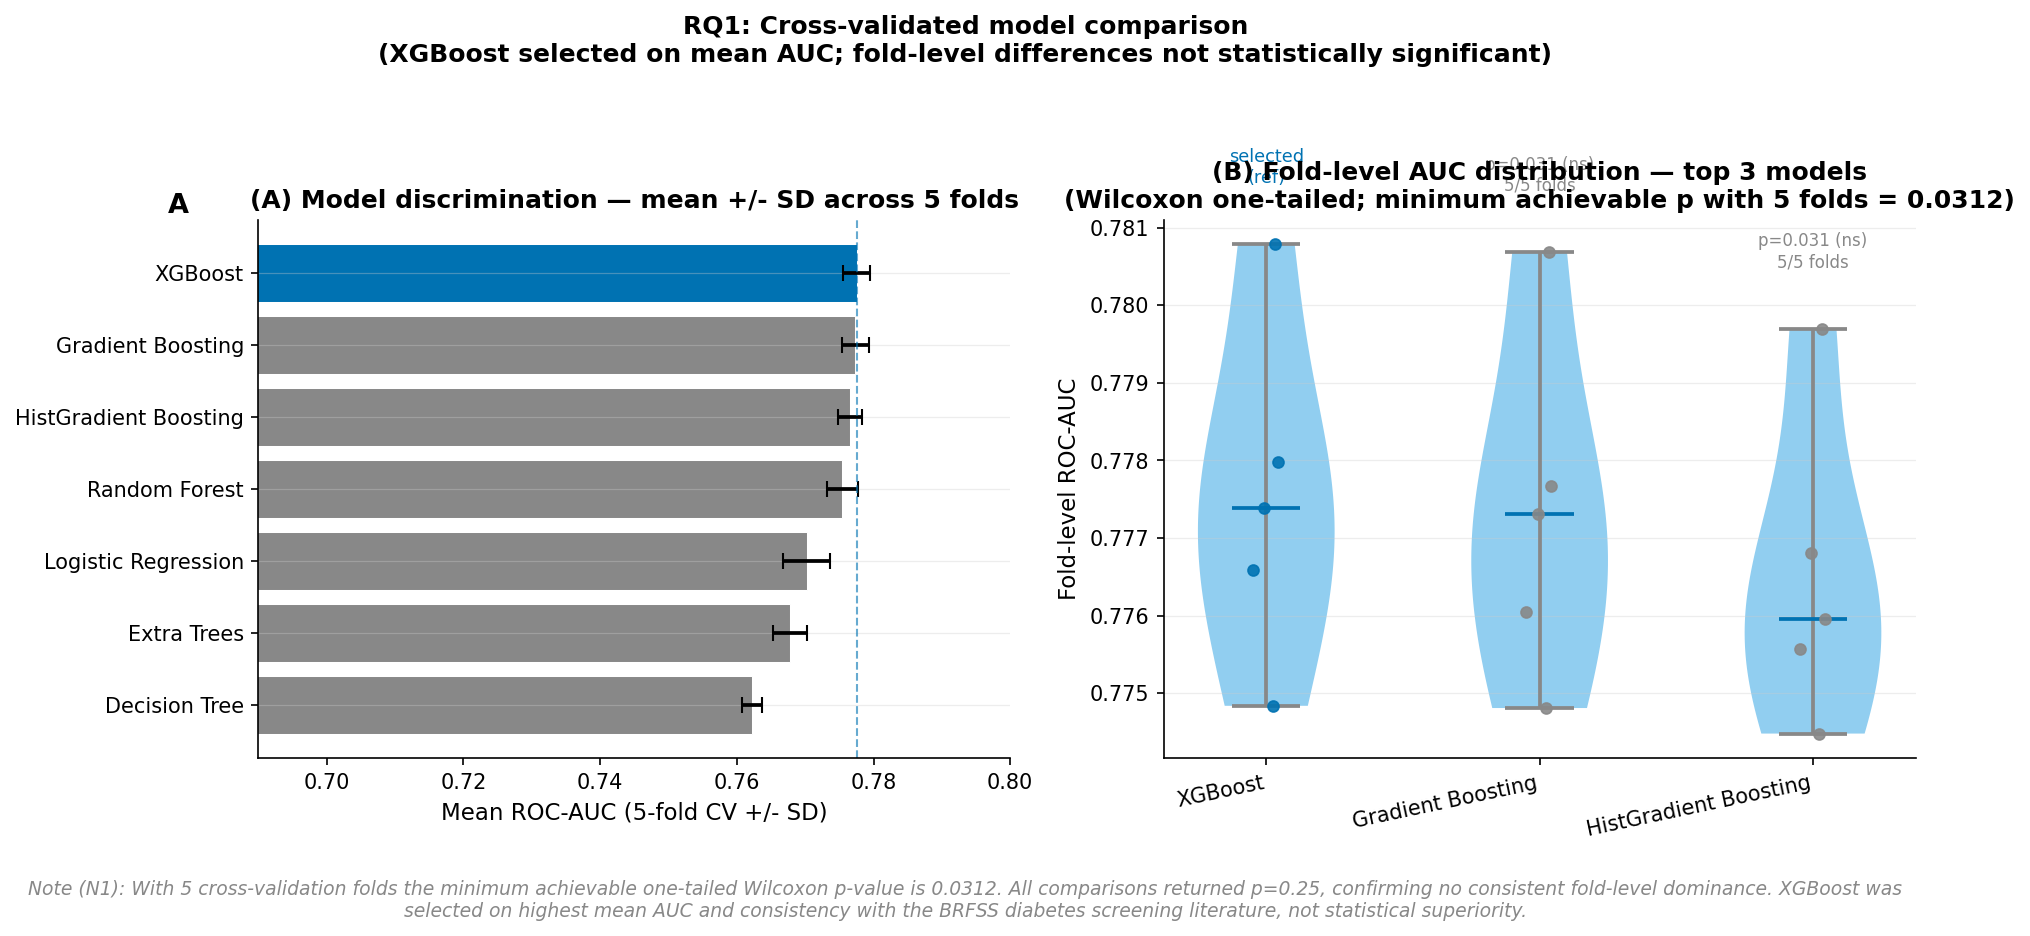

PosixPath('/kaggle/working/batool_jms_revised_outputs/figures/rq1_cv_model_comparison_with_wilcoxon.pdf')

In [12]:
# ============================================================
# RQ1 Fig A: Cross-validated model comparison figure
#    FIX N1: Power-limit annotation; honest title and subtitle
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
bar_colors = [C["blue"] if m == best_model_name else C["gray"] for m in cv_results["model"]]
ax.barh(cv_results["model"][::-1],
        cv_results["roc_auc_mean"][::-1],
        xerr=cv_results["roc_auc_sd"][::-1],
        color=bar_colors[::-1], capsize=4, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Mean ROC-AUC (5-fold CV +/- SD)")
ax.set_xlim(0.69, 0.80)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.axvline(cv_results.iloc[0]["roc_auc_mean"], color=C["blue"], ls="--", lw=1, alpha=0.6)
ax.set_title("(A) Model discrimination — mean +/- SD across 5 folds", fontweight="bold")
add_panel_label(ax, "A")

ax2 = axes[1]
top3 = cv_results["model"].head(3).tolist()
fold_data = [cv_fold_aucs[m] for m in top3]

parts = ax2.violinplot(fold_data, positions=range(len(top3)),
                       showmedians=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_facecolor(C["sky"])
    pc.set_alpha(0.65)
parts["cmedians"].set_color(C["blue"])
parts["cmaxes"].set_color(C["gray"])
parts["cmins"].set_color(C["gray"])
parts["cbars"].set_color(C["gray"])

for xi, m in enumerate(top3):
    jitter = np.random.default_rng(42).uniform(-0.06, 0.06, len(cv_fold_aucs[m]))
    ax2.scatter(xi + jitter, cv_fold_aucs[m], s=28,
                color=C["blue"] if m == best_model_name else C["gray"],
                zorder=4, alpha=0.9)

ax2.set_xticks(range(len(top3)))
ax2.set_xticklabels(top3, rotation=12, ha="right")
ax2.set_ylabel("Fold-level ROC-AUC")
ax2.set_title(
    "(B) Fold-level AUC distribution — top 3 models\n"
    f"(Wilcoxon one-tailed; minimum achievable p with {N_SPLITS_CV} folds = {WILCOXON_MIN_P:.4f})",
    fontweight="bold",
)
ax2.yaxis.grid(True, alpha=0.35)

for j, m in enumerate(top3):
    y_annot = max(cv_fold_aucs[m]) + 0.0008
    if m == best_model_name:
        ax2.text(j, y_annot, "selected\n(ref)", ha="center", fontsize=8.5,
                 color=C["blue"], fontweight="500")
    else:
        match = wilcoxon_df[wilcoxon_df["model_b"] == m]
        if len(match):
            r = match.iloc[0]
            pv  = float(r["p_value"])
            won = int(r["folds_model_a_better"])
            ax2.text(j, y_annot, f"p={pv:.3f} (ns)\n{won}/{N_SPLITS_CV} folds",
                     ha="center", fontsize=8, color=C["gray"])

fig.text(
    0.5, -0.06,
    f"Note (N1): With {N_SPLITS_CV} cross-validation folds the minimum achievable one-tailed "
    f"Wilcoxon p-value is {WILCOXON_MIN_P:.4f}. All comparisons returned p=0.25, confirming "
    f"no consistent fold-level dominance. {best_model_name} was selected on highest mean AUC "
    f"and consistency with the BRFSS diabetes screening literature, not statistical superiority.",
    ha="center", fontsize=9, style="italic", color=C["gray"], wrap=True,
)
plt.suptitle(
    f"RQ1: Cross-validated model comparison\n"
    f"({best_model_name} selected on mean AUC; fold-level differences not statistically significant)",
    fontsize=12, fontweight="bold", y=1.03,
)
savefig("rq1_cv_model_comparison_with_wilcoxon.pdf")

In [13]:
# ============================================================
# 9. Calibrated threshold selection & final model fitting
# ============================================================
print(f"\nFitting calibrated model: {best_model_name}")

# Threshold selection uses calibrated validation probabilities (C2 fix)
X_inner, X_val, y_inner, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE_WITHIN_TRAIN, stratify=y_train, random_state=RANDOM_STATE,
)
base_thresh = build_models(SELECTED_FEATURES, RANDOM_STATE)[best_model_name]
cal_thresh  = CalibratedClassifierCV(base_thresh, method="isotonic", cv=3)
cal_thresh.fit(X_inner, y_inner)
val_prob    = predict_proba_pos(cal_thresh, X_val)

thresholds, threshold_curve = choose_thresholds(y_val, val_prob, TARGET_RECALL)
threshold_curve.to_csv(TABLE_DIR / "threshold_selection_curve_calibrated_validation.csv", index=False)

thr_table = pd.DataFrame([
    {"threshold_strategy": k, "threshold": v,
     "selected_using": "calibrated_validation_probabilities"}
    for k, v in thresholds.items()
])
save_table(thr_table, "selected_screening_thresholds.csv")

# Final calibrated model on full training set
base_final = build_models(SELECTED_FEATURES, RANDOM_STATE)[best_model_name]
calibrated_model = CalibratedClassifierCV(base_final, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)
test_prob = predict_proba_pos(calibrated_model, X_test)

if joblib:
    joblib.dump(calibrated_model, MODEL_DIR / "best_calibrated_model.joblib")
    with open(MODEL_DIR / "model_metadata.json", "w") as f:
        json.dump({"best_model_name": best_model_name,
                   "features": SELECTED_FEATURES,
                   "calibration": "isotonic_cv5",
                   "thresholds": thresholds,
                   "note_C2": (
                       "This model was calibrated on a 50/50 balanced dataset. "
                       "Predicted probabilities are not directly interpretable as "
                       "absolute risk at natural diabetes prevalence (~14%). "
                       "Prevalence-adjusted recalibration is required for deployment."
                   )}, f, indent=2)

main_strategy   = "default_0_50"
screen_strategy = [k for k in thresholds if k.startswith("recall_at_least")][0]
MAIN_THRESHOLD   = thresholds[main_strategy]
SCREEN_THRESHOLD = thresholds[screen_strategy]

print(f"Default threshold:   {MAIN_THRESHOLD:.2f}")
print(f"Youden-J threshold:  {thresholds['youden_j']:.2f}  "
      f"(higher than 0.50; trades recall for precision — less suited for screening)")
print(f"Screening threshold: {SCREEN_THRESHOLD:.2f}  ← recommended for low-resource screening use case")

# FIX A2: Save threshold rationale note
with open(OUTPUT_ROOT / "threshold_clinical_rationale.txt", "w") as f:
    f.write(
        f"Three operating thresholds were evaluated.\n"
        f"  Default (0.50): conventional decision boundary; balanced precision/recall.\n"
        f"  Youden-J ({thresholds['youden_j']:.2f}): maximises sensitivity + specificity sum; "
        f"counterintuitively raises threshold above 0.50 in a balanced dataset, reducing recall.\n"
        f"  Screening threshold ({SCREEN_THRESHOLD:.2f}): lowers threshold to achieve ≥{int(TARGET_RECALL*100)}% recall, "
        f"prioritising case detection over precision. This is the recommended threshold "
        f"for low-resource preliminary screening use cases where missing a diabetic case "
        f"(false negative) carries higher cost than a false alarm.\n"
    )
print("  ✓ text  → threshold_clinical_rationale.txt")


Fitting calibrated model: XGBoost
  ✓ table  → selected_screening_thresholds.csv


,threshold_strategy,threshold,selected_using
0,default_0_50,0.50,calibrated_validation_probabilities
1,youden_j,0.53,calibrated_validation_probabilities
2,recall_at_least_80,0.35,calibrated_validation_probabilities


Default threshold:   0.50
Youden-J threshold:  0.53  (higher than 0.50; trades recall for precision — less suited for screening)
Screening threshold: 0.35  ← recommended for low-resource screening use case
  ✓ text  → threshold_clinical_rationale.txt


  ✓ figure → threshold_selection_curve_calibrated_validation.pdf


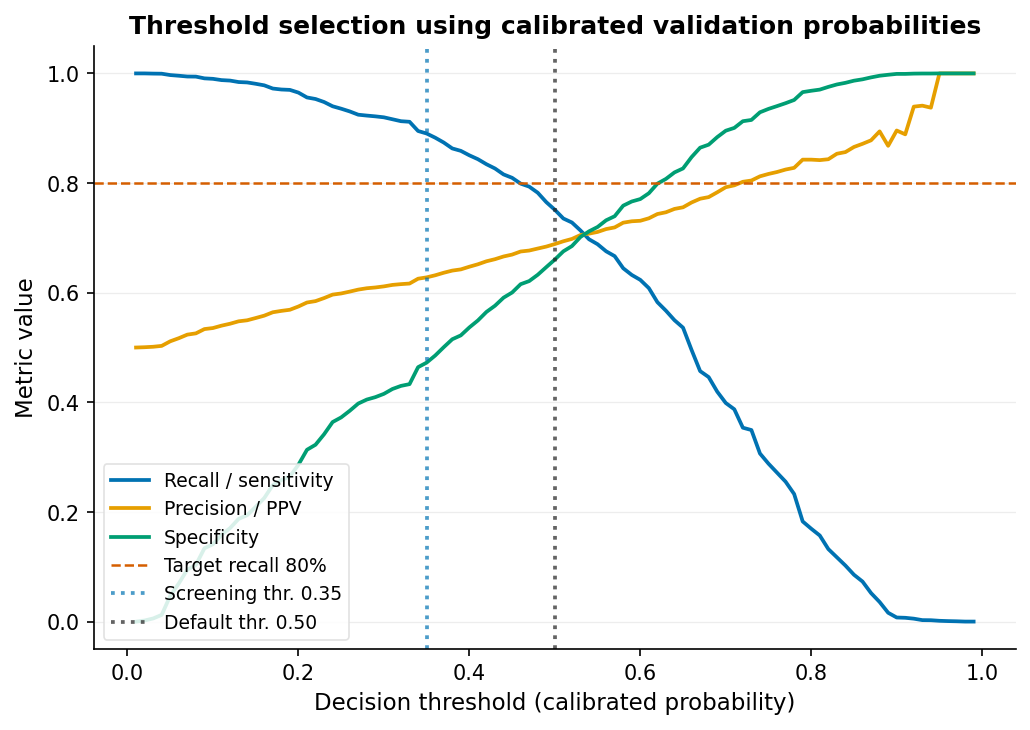

  ✓ table  → rq1_primary_test_metrics_by_threshold.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,false_positive_rate,false_negative_rate,predicted_positive_rate,n,positive_prevalence,calibration_intercept,calibration_slope,dataset,model,threshold_strategy
0,0.50,0.709951,0.709955,0.690501,0.760928,0.658982,0.724006,0.780867,0.189929,0.009114,...,0.341018,0.239072,0.550958,14139,0.499965,0.003141,1.005173,primary_balanced_internal_test,XGBoost + isotonic calibration,default_0_50
1,0.53,0.707051,0.707052,0.702169,0.719055,0.695050,0.710512,0.780867,0.189929,0.009114,...,0.304950,0.280945,0.511988,14139,0.499965,0.003141,1.005173,primary_balanced_internal_test,XGBoost + isotonic calibration,youden_j
2,0.35,0.683429,0.683444,0.628710,0.895883,0.471004,0.738887,0.780867,0.189929,0.009114,...,0.528996,0.104117,0.712427,14139,0.499965,0.003141,1.005173,primary_balanced_internal_test,XGBoost + isotonic calibration,recall_at_least_80


  ✓ table  → rq1_primary_test_bootstrap_ci_default_threshold.csv


,metric,mean_bootstrap,ci95_low,ci95_high
0,accuracy,0.709872,0.701956,0.716707
1,precision,0.690229,0.680072,0.699629
2,recall_sensitivity,0.760783,0.750831,0.770756
3,specificity,0.659028,0.647676,0.668883
4,f1_score,0.723777,0.715626,0.731592
5,roc_auc,0.780793,0.773069,0.788158
6,brier_score,0.189949,0.186952,0.193029
7,ece_10bin,0.012229,0.007160,0.018428
8,false_positive_rate,0.340972,0.331117,0.352324
9,false_negative_rate,0.239217,0.229244,0.249169


  ✓ table  → rq1_primary_test_bootstrap_ci_screening_threshold.csv


,metric,mean_bootstrap,ci95_low,ci95_high
0,accuracy,0.683304,0.675400,0.690892
1,precision,0.628452,0.619048,0.637799
2,recall_sensitivity,0.895769,0.888873,0.902212
3,specificity,0.471126,0.458776,0.482696
4,f1_score,0.738658,0.731153,0.745753
5,roc_auc,0.780793,0.773069,0.788158
6,brier_score,0.189949,0.186952,0.193029
7,ece_10bin,0.012229,0.007160,0.018428
8,false_positive_rate,0.528874,0.517304,0.541224
9,false_negative_rate,0.104231,0.097788,0.111127


  ✓ figure → rq1_overall_performance_panel.pdf


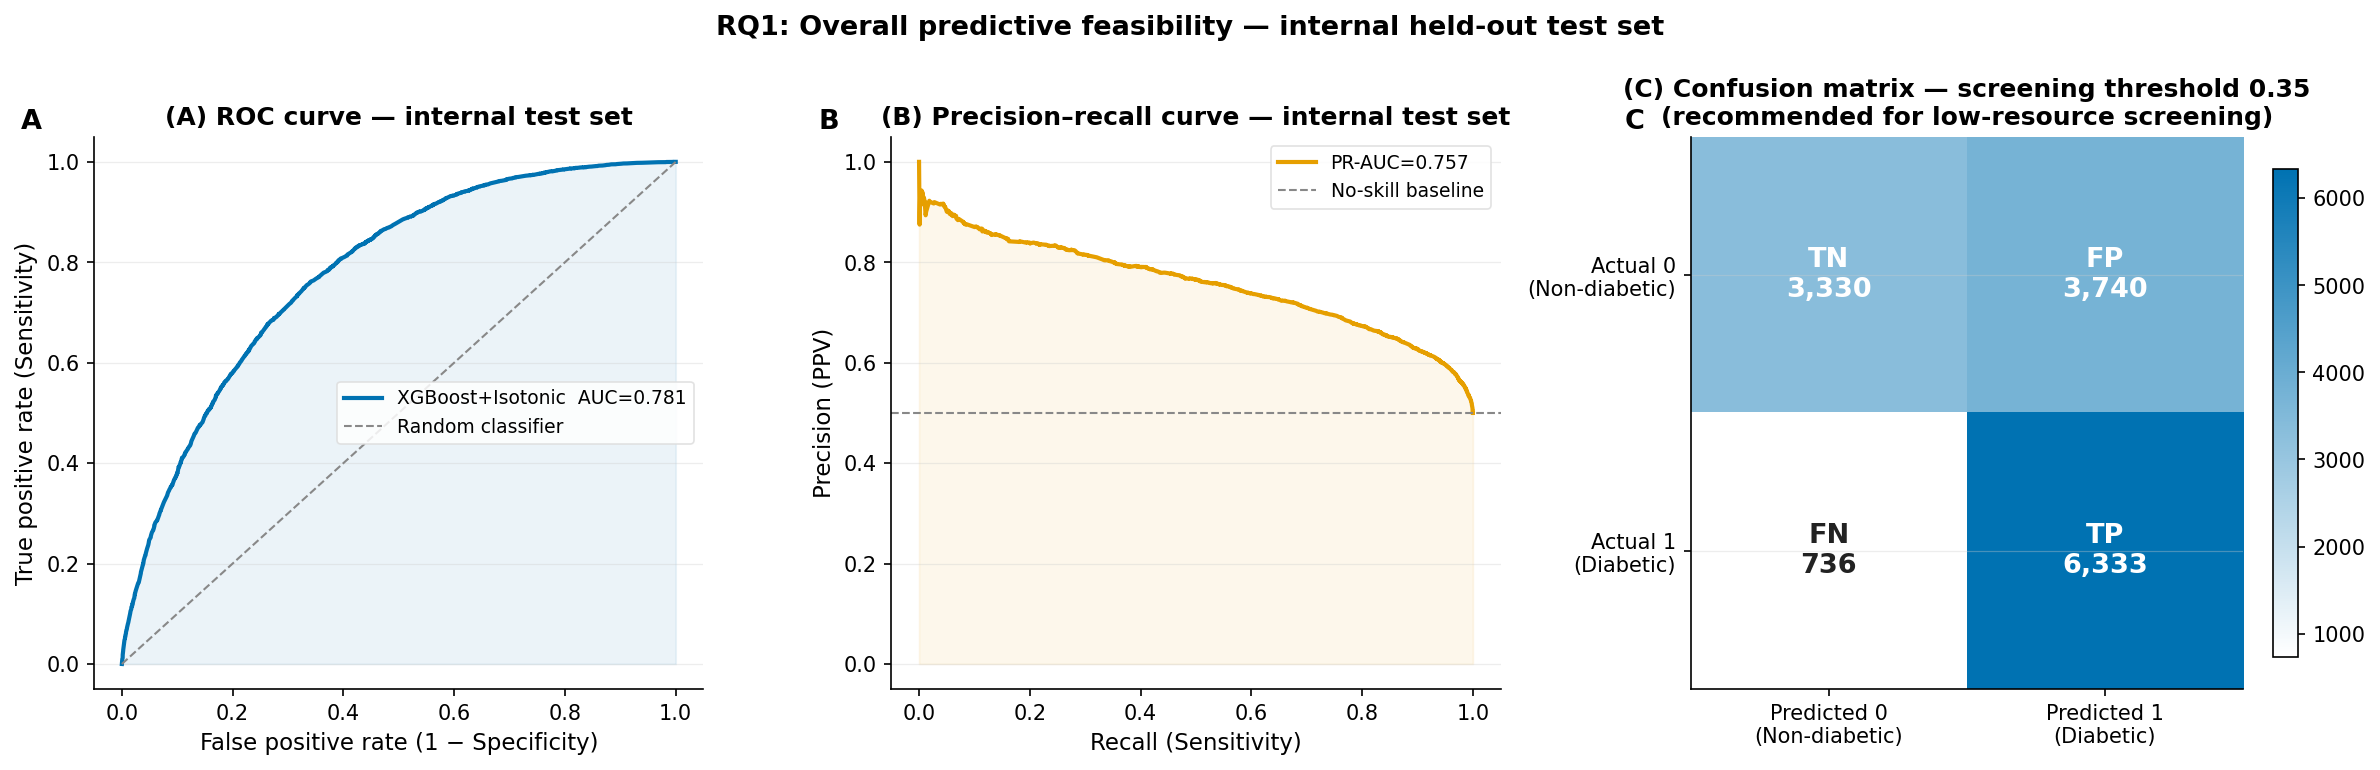

  ✓ figure → rq1_confusion_matrix_default.pdf


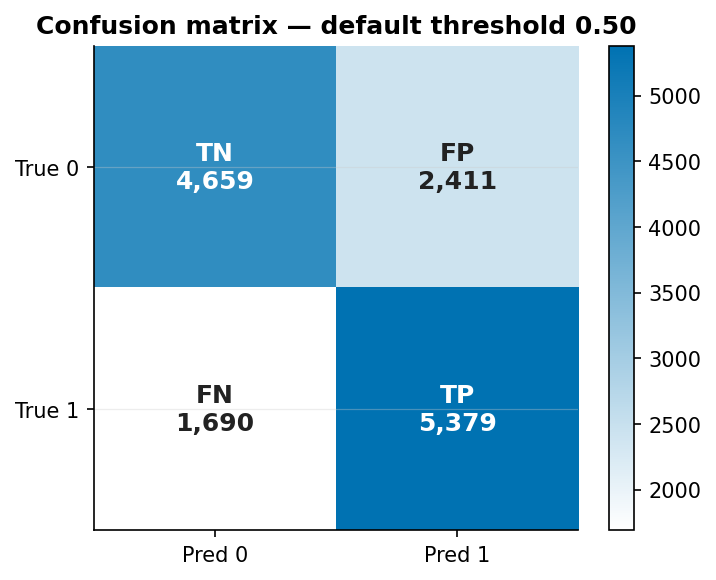

PosixPath('/kaggle/working/batool_jms_revised_outputs/figures/rq1_confusion_matrix_default.pdf')

In [14]:
# ============================================================
# 10. Internal held-out test performance (RQ1)
# ============================================================

# ── Threshold curve figure ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
tc = threshold_curve
ax.plot(tc["threshold"], tc["recall_sensitivity"], color=C["blue"],   label="Recall / sensitivity")
ax.plot(tc["threshold"], tc["precision"],          color=C["orange"], label="Precision / PPV")
ax.plot(tc["threshold"], tc["specificity"],        color=C["green"],  label="Specificity")
ax.axhline(TARGET_RECALL, ls="--", color=C["red"], lw=1.2, label=f"Target recall {TARGET_RECALL:.0%}")
ax.axvline(SCREEN_THRESHOLD, ls=":",  color=C["blue"],   alpha=0.7,
           label=f"Screening thr. {SCREEN_THRESHOLD:.2f}")
ax.axvline(MAIN_THRESHOLD,   ls=":",  color=C["black"],  alpha=0.7,
           label=f"Default thr. {MAIN_THRESHOLD:.2f}")
ax.set_xlabel("Decision threshold (calibrated probability)")
ax.set_ylabel("Metric value")
ax.set_title("Threshold selection using calibrated validation probabilities")
ax.legend(loc="lower left", fontsize=9)
savefig("threshold_selection_curve_calibrated_validation.pdf")

# ── Per-threshold metrics ───────────────────────────────────────────────────
eval_rows = []
for strategy, thr in thresholds.items():
    row = metrics_at_threshold(y_test, test_prob, thr)
    row.update({"dataset": "primary_balanced_internal_test",
                "model":   best_model_name + " + isotonic calibration",
                "threshold_strategy": strategy})
    eval_rows.append(row)
primary_test_metrics = pd.DataFrame(eval_rows)
save_table(primary_test_metrics, "rq1_primary_test_metrics_by_threshold.csv", n=5)

# ── Bootstrap CI (500 iterations) ──────────────────────────────────────────
ci_default = bootstrap_ci(y_test, test_prob, MAIN_THRESHOLD)
save_table(ci_default, "rq1_primary_test_bootstrap_ci_default_threshold.csv")
ci_screen = bootstrap_ci(y_test, test_prob, SCREEN_THRESHOLD)
save_table(ci_screen,  "rq1_primary_test_bootstrap_ci_screening_threshold.csv")

# ── Publication ROC + PR + Confusion matrix figure ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, test_prob)
axes[0].plot(fpr, tpr, color=C["blue"], lw=2,
             label=f"XGBoost+Isotonic  AUC={auc(fpr,tpr):.3f}")
axes[0].plot([0,1],[0,1],"--", color=C["gray"], lw=1, label="Random classifier")
axes[0].fill_between(fpr, tpr, alpha=0.08, color=C["blue"])
axes[0].set_xlabel("False positive rate (1 − Specificity)")
axes[0].set_ylabel("True positive rate (Sensitivity)")
axes[0].set_title("(A) ROC curve — internal test set")
axes[0].legend(fontsize=9)
add_panel_label(axes[0], "A")

# PR
prec, rec, _ = precision_recall_curve(y_test, test_prob)
pr_auc = auc(rec, prec)
axes[1].plot(rec, prec, color=C["orange"], lw=2, label=f"PR-AUC={pr_auc:.3f}")
axes[1].axhline(float(y_test.mean()), ls="--", color=C["gray"], lw=1, label="No-skill baseline")
axes[1].fill_between(rec, prec, alpha=0.08, color=C["orange"])
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision (PPV)")
axes[1].set_title("(B) Precision–recall curve — internal test set")
axes[1].legend(fontsize=9)
add_panel_label(axes[1], "B")

# Confusion matrix (screening threshold)
y_pred_screen = (test_prob >= SCREEN_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred_screen, labels=[0, 1])
cmap = LinearSegmentedColormap.from_list("blues", ["#FFFFFF", C["blue"]], N=256)
im = axes[2].imshow(cm, cmap=cmap)
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        txt = f"{labels[i][j]}\n{cm[i,j]:,}"
        axes[2].text(j, i, txt, ha="center", va="center",
                     fontsize=13, fontweight="bold",
                     color="white" if cm[i,j] > cm.max()*0.5 else C["black"])
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(["Predicted 0\n(Non-diabetic)", "Predicted 1\n(Diabetic)"])
axes[2].set_yticklabels(["Actual 0\n(Non-diabetic)", "Actual 1\n(Diabetic)"])
axes[2].set_title(f"(C) Confusion matrix — screening threshold {SCREEN_THRESHOLD:.2f}\n"
                  f"(recommended for low-resource screening)")
plt.colorbar(im, ax=axes[2], fraction=0.04)
add_panel_label(axes[2], "C")

plt.suptitle("RQ1: Overall predictive feasibility — internal held-out test set",
             fontsize=13, fontweight="bold", y=1.02)
savefig("rq1_overall_performance_panel.pdf")

# Default-threshold confusion matrix (separate figure for supplementary)
fig, ax = plt.subplots(figsize=(5, 4))
y_pred_def = (test_prob >= MAIN_THRESHOLD).astype(int)
cm_def = confusion_matrix(y_test, y_pred_def, labels=[0,1])
im2 = ax.imshow(cm_def, cmap=cmap)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{['TN','FP','FN','TP'][i*2+j]}\n{cm_def[i,j]:,}",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="white" if cm_def[i,j] > cm_def.max()*0.5 else C["black"])
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred 0","Pred 1"]); ax.set_yticklabels(["True 0","True 1"])
ax.set_title(f"Confusion matrix — default threshold {MAIN_THRESHOLD:.2f}")
plt.colorbar(im2, ax=ax, fraction=0.04)
savefig("rq1_confusion_matrix_default.pdf")

  ✓ table  → rq2_permutation_importance.csv


,feature,permutation_importance_mean,permutation_importance_sd
0,BMI,0.107310,0.005047
1,Age,0.089485,0.002481
2,Income,0.024961,0.003298
3,Sex,0.004894,0.000703
4,HvyAlcoholConsump,0.004316,0.000952
5,PhysActivity,0.003196,0.000809
6,Education,0.002789,0.000845
7,Smoker,0.000832,0.000480
8,Fruits,0.000494,0.000306
9,Veggies,0.000378,0.000256


ExactExplainer explainer: 1001it [13:14,  1.26it/s]                          

  ✓ table  → rq2_shap_mean_absolute_importance.csv


,feature,mean_absolute_shap_value
0,BMI,0.122790
1,Age,0.106720
2,Income,0.057726
3,Sex,0.028171
4,PhysActivity,0.020851
5,Education,0.014533
6,Smoker,0.009617
7,HvyAlcoholConsump,0.008489
8,Veggies,0.004841
9,Fruits,0.004149


SHAP computed successfully.
  ✓ table  → rq2_feature_group_contribution.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,true_positive,false_positive_rate,false_negative_rate,predicted_positive_rate,n,positive_prevalence,calibration_intercept,calibration_slope,feature_set,features_kept
0,0.5,0.656765,0.656772,0.631249,0.753855,0.559689,0.687125,0.716335,0.212940,0.009806,...,5329,0.440311,0.246145,0.597072,14139,0.499965,0.003324,1.032431,remove_lifestyle,"Sex, Age, Education, Income"
1,0.5,0.655987,0.655990,0.644476,0.695714,0.616266,0.669116,0.713057,0.215427,0.009107,...,4918,0.383734,0.304286,0.539713,14139,0.499965,0.002890,1.010250,remove_demographic,"BMI, Smoker, PhysActivity, Fruits, Veggies, Hv..."
2,0.5,0.709951,0.709955,0.690501,0.760928,0.658982,0.724006,0.780867,0.189929,0.009114,...,5379,0.341018,0.239072,0.550958,14139,0.499965,0.003141,1.005173,all_selected_features,"BMI, Smoker, PhysActivity, Fruits, Veggies, Hv..."


  ✓ table  → rq2_permutation_vs_shap_comparison.csv


,feature,permutation_mean,shap_mean,perm_rank,shap_rank,rank_diff,perm_norm,shap_norm,scale_ratio,discrepancy_note
0,BMI,0.107310,0.122790,1.0,1.0,0.0,1.000000,1.000000,0.999999,Consistent
1,Age,0.089485,0.106720,2.0,2.0,0.0,0.833892,0.869125,1.042250,Consistent
2,Income,0.024961,0.057726,3.0,3.0,0.0,0.232603,0.470122,2.021129,Moderate discrepancy
3,Sex,0.004894,0.028171,4.0,4.0,0.0,0.045605,0.229423,5.030539,Large-scale discrepancy (likely correlated lif...
4,HvyAlcoholConsump,0.004316,0.008489,5.0,8.0,3.0,0.040218,0.069138,1.719009,Moderate discrepancy
5,PhysActivity,0.003196,0.020851,6.0,5.0,1.0,0.029783,0.169811,5.701461,Large-scale discrepancy (likely correlated lif...
6,Education,0.002789,0.014533,7.0,6.0,1.0,0.025992,0.118358,4.553416,Large-scale discrepancy (likely correlated lif...
7,Smoker,0.000832,0.009617,8.0,7.0,1.0,0.007755,0.078321,10.098634,Large-scale discrepancy (likely correlated lif...
8,Fruits,0.000494,0.004149,9.0,10.0,1.0,0.004600,0.033786,7.342963,Large-scale discrepancy (likely correlated lif...
9,Veggies,0.000378,0.004841,10.0,9.0,1.0,0.003520,0.039421,11.195180,Large-scale discrepancy (likely correlated lif...


  ✓ figure → rq2_feature_importance_panel.pdf


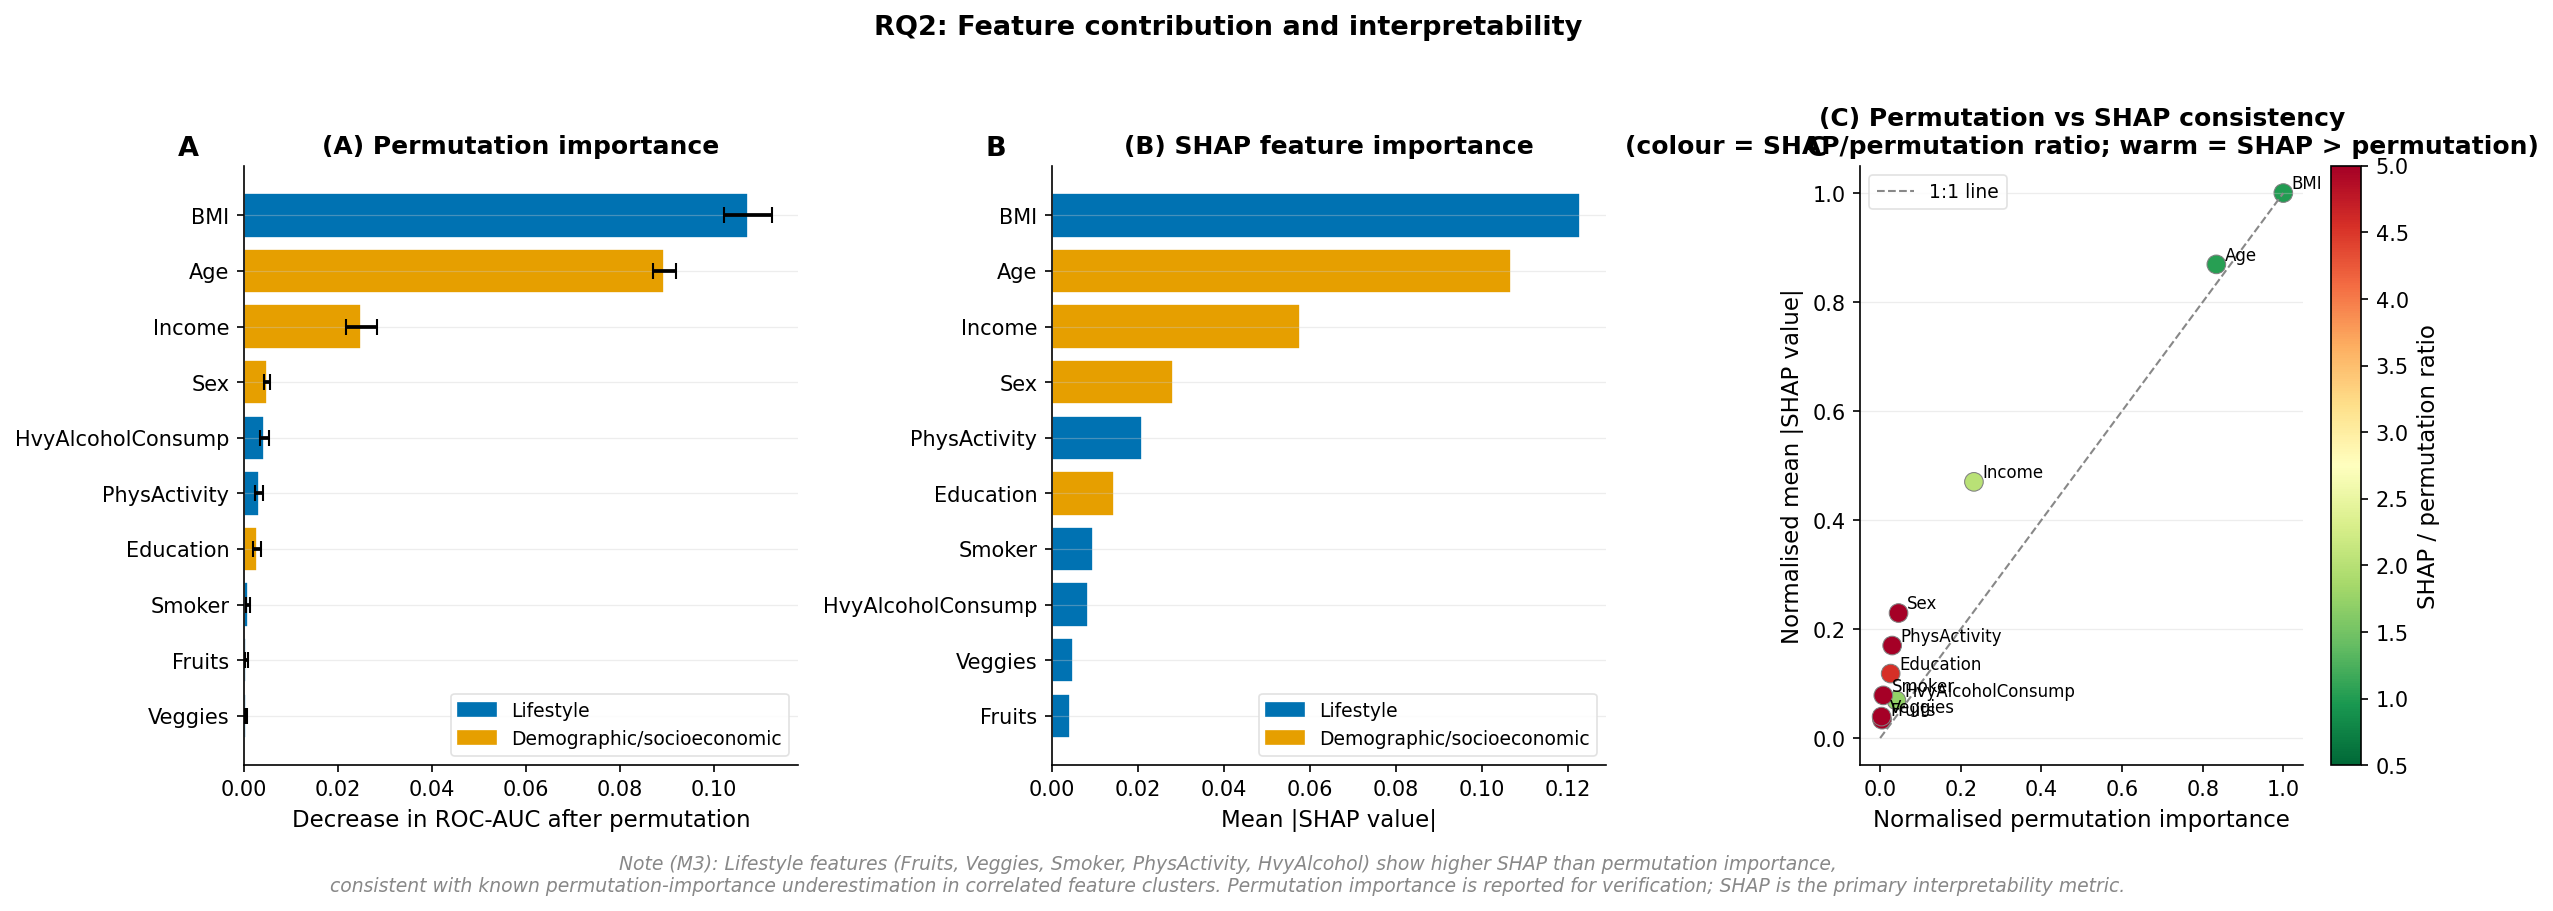

PosixPath('/kaggle/working/batool_jms_revised_outputs/figures/rq2_feature_importance_panel.pdf')

In [15]:
# ============================================================
# 11. Feature contribution and interpretability (RQ2)
#     FIX M3: Permutation vs SHAP discrepancy analysis added
# ============================================================

# --- Permutation importance ---
perm_n = min(PERMUTATION_SAMPLE_SIZE, len(X_test))
perm_X = X_test.sample(perm_n, random_state=RANDOM_STATE)
perm_y = y_test.loc[perm_X.index]
pi = permutation_importance(calibrated_model, perm_X, perm_y,
                            scoring="roc_auc", n_repeats=10,
                            random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "permutation_importance_mean": pi.importances_mean,
    "permutation_importance_sd":   pi.importances_std,
}).sort_values("permutation_importance_mean", ascending=False).reset_index(drop=True)
save_table(perm_df, "rq2_permutation_importance.csv")

# --- SHAP ---
shap_df = None
if SHAP_AVAILABLE:
    try:
        shap_n  = min(SHAP_SAMPLE_SIZE, len(X_test))
        shap_X  = X_test.sample(shap_n, random_state=RANDOM_STATE)
        bg      = X_train.sample(min(200, len(X_train)), random_state=RANDOM_STATE)
        explainer = shap.Explainer(
            lambda data: predict_proba_pos(calibrated_model, pd.DataFrame(data, columns=SELECTED_FEATURES)),
            bg
        )
        shap_vals = explainer(shap_X)
        shap_abs  = np.abs(shap_vals.values).mean(axis=0)
        shap_df   = pd.DataFrame({"feature": SELECTED_FEATURES,
                                  "mean_absolute_shap_value": shap_abs}
                                 ).sort_values("mean_absolute_shap_value", ascending=False).reset_index(drop=True)
        save_table(shap_df, "rq2_shap_mean_absolute_importance.csv")
        print("SHAP computed successfully.")
    except Exception as e:
        print("SHAP failed, permutation importance is primary:", repr(e))

# --- Feature group ablation ---
group_rows = []
for group_name, remove_feats in {"remove_lifestyle": LIFESTYLE_FEATURES,
                                  "remove_demographic": DEMOGRAPHIC_FEATURES}.items():
    kept = [f for f in SELECTED_FEATURES if f not in remove_feats]
    if not kept:
        continue
    avail = build_models(kept, RANDOM_STATE)
    m_name = best_model_name if best_model_name in avail else "Logistic Regression"
    m = CalibratedClassifierCV(avail[m_name], method="isotonic", cv=3)
    m.fit(X_train[kept], y_train)
    prob = predict_proba_pos(m, X_test[kept])
    row = metrics_at_threshold(y_test, prob, MAIN_THRESHOLD)
    row.update({"feature_set": group_name, "features_kept": ", ".join(kept)})
    group_rows.append(row)
full_row = metrics_at_threshold(y_test, test_prob, MAIN_THRESHOLD)
full_row.update({"feature_set": "all_selected_features",
                 "features_kept": ", ".join(SELECTED_FEATURES)})
group_rows.append(full_row)
feature_group_df = pd.DataFrame(group_rows)
save_table(feature_group_df, "rq2_feature_group_contribution.csv")

# ── FIX M3: Permutation vs SHAP comparison and discrepancy analysis ────────
if shap_df is not None:
    # Merge the two importance measures
    compare_df = perm_df.set_index("feature")[["permutation_importance_mean"]].join(
        shap_df.set_index("feature")[["mean_absolute_shap_value"]]
    ).reset_index()
    compare_df.columns = ["feature", "permutation_mean", "shap_mean"]
    compare_df["perm_rank"]  = compare_df["permutation_mean"].rank(ascending=False)
    compare_df["shap_rank"]  = compare_df["shap_mean"].rank(ascending=False)
    compare_df["rank_diff"]  = (compare_df["perm_rank"] - compare_df["shap_rank"]).abs()
    # Normalise for ratio comparison
    pm_max = compare_df["permutation_mean"].max()
    sm_max = compare_df["shap_mean"].max()
    compare_df["perm_norm"] = compare_df["permutation_mean"] / (pm_max + 1e-12)
    compare_df["shap_norm"] = compare_df["shap_mean"]        / (sm_max + 1e-12)
    compare_df["scale_ratio"] = compare_df["shap_norm"] / (compare_df["perm_norm"] + 1e-6)
    compare_df["discrepancy_note"] = compare_df.apply(
        lambda r: (
            "Large-scale discrepancy (likely correlated lifestyle cluster underestimated by permutation)"
            if r["scale_ratio"] > 3 else
            ("Moderate discrepancy" if r["scale_ratio"] > 1.5 else "Consistent")
        ), axis=1
    )
    save_table(compare_df, "rq2_permutation_vs_shap_comparison.csv")

# ── Publication figure: permutation importance + SHAP comparison ───────────
n_panels = 3 if shap_df is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5.5))

# Permutation importance
ax = axes[0]
perm_sorted = perm_df.sort_values("permutation_importance_mean")
colors_perm = [C["blue"] if f in LIFESTYLE_FEATURES else C["orange"] for f in perm_sorted["feature"]]
ax.barh(perm_sorted["feature"], perm_sorted["permutation_importance_mean"],
        xerr=perm_sorted["permutation_importance_sd"],
        color=colors_perm, capsize=4, edgecolor="white")
ax.set_xlabel("Decrease in ROC-AUC after permutation")
ax.set_title("(A) Permutation importance")
patches = [mpatches.Patch(color=C["blue"], label="Lifestyle"),
           mpatches.Patch(color=C["orange"], label="Demographic/socioeconomic")]
ax.legend(handles=patches, fontsize=9, loc="lower right")
add_panel_label(ax, "A")

# SHAP if available
if shap_df is not None:
    ax2 = axes[1]
    shap_sorted = shap_df.sort_values("mean_absolute_shap_value")
    colors_shap = [C["blue"] if f in LIFESTYLE_FEATURES else C["orange"]
                   for f in shap_sorted["feature"]]
    ax2.barh(shap_sorted["feature"], shap_sorted["mean_absolute_shap_value"],
             color=colors_shap, edgecolor="white")
    ax2.set_xlabel("Mean |SHAP value|")
    ax2.set_title("(B) SHAP feature importance")
    ax2.legend(handles=patches, fontsize=9, loc="lower right")
    add_panel_label(ax2, "B")

    # FIX M3: side-by-side scatter to visualise discrepancy
    ax3 = axes[2]
    x = compare_df["perm_norm"]
    y_shap = compare_df["shap_norm"]
    sc = ax3.scatter(x, y_shap, c=compare_df["scale_ratio"],
                     cmap="RdYlGn_r", s=80, edgecolors="gray", linewidth=0.5,
                     vmin=0.5, vmax=5)
    for _, row in compare_df.iterrows():
        ax3.annotate(row["feature"], (row["perm_norm"], row["shap_norm"]),
                     textcoords="offset points", xytext=(4, 2), fontsize=8)
    ax3.plot([0, 1], [0, 1], "--", color=C["gray"], lw=1, label="1:1 line")
    ax3.set_xlabel("Normalised permutation importance")
    ax3.set_ylabel("Normalised mean |SHAP value|")
    ax3.set_title("(C) Permutation vs SHAP consistency\n"
                  "(colour = SHAP/permutation ratio; warm = SHAP > permutation)")
    plt.colorbar(sc, ax=ax3, label="SHAP / permutation ratio")
    ax3.legend(fontsize=9)
    add_panel_label(ax3, "C")

    # M3 discrepancy explanation in figure note
    fig.text(0.5, -0.04,
             "Note (M3): Lifestyle features (Fruits, Veggies, Smoker, PhysActivity, HvyAlcohol) "
             "show higher SHAP than permutation importance,\nconsistent with known "
             "permutation-importance underestimation in correlated feature clusters. "
             "Permutation importance is reported for verification; SHAP is the primary interpretability metric.",
             ha="center", fontsize=9, style="italic", color=C["gray"],
             wrap=True)

plt.suptitle("RQ2: Feature contribution and interpretability",
             fontsize=13, fontweight="bold", y=1.02)
savefig("rq2_feature_importance_panel.pdf")

  ✓ table  → rq3_age_subgroup_reliability_metrics.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,n,positive_prevalence,calibration_intercept,calibration_slope,subgroup_variable,subgroup,n_positive,n_total,reliability_note,threshold_strategy
0,0.50,0.890231,0.561369,0.500000,0.140000,0.982737,0.218750,0.767269,0.085921,0.019590,...,911,0.109769,-0.213223,0.992710,AgeGroup,18–34,100,911,CAUTION: fewer than 150 positive cases; estima...,default_0_50
1,0.50,0.742376,0.618844,0.615789,0.320548,0.917140,0.421622,0.773285,0.170457,0.035691,...,1246,0.292937,0.118472,0.962440,AgeGroup,35–44,365,1246,,default_0_50
2,0.50,0.704046,0.686514,0.642353,0.596721,0.776306,0.618697,0.761628,0.193955,0.025038,...,2274,0.402375,-0.094198,0.949476,AgeGroup,45–54,915,2274,,default_0_50
3,0.50,0.693497,0.688525,0.699449,0.754212,0.622837,0.725799,0.755011,0.199650,0.018105,...,3752,0.537846,0.048211,0.982069,AgeGroup,55–64,2018,3752,,default_0_50
4,0.50,0.697736,0.644506,0.708927,0.868141,0.420871,0.780497,0.733182,0.198149,0.009155,...,3798,0.619010,-0.034479,1.073060,AgeGroup,65–74,2351,3798,,default_0_50
5,0.50,0.671455,0.616404,0.683263,0.862879,0.369928,0.762638,0.698964,0.209470,0.016097,...,2158,0.611677,-0.020899,1.040320,AgeGroup,75+,1320,2158,,default_0_50
6,0.53,0.895719,0.564451,0.608696,0.140000,0.988903,0.227642,0.767269,0.085921,0.019590,...,911,0.109769,-0.213223,0.992710,AgeGroup,18–34,100,911,CAUTION: fewer than 150 positive cases; estima...,youden_j
7,0.53,0.740770,0.608883,0.623529,0.290411,0.927355,0.396262,0.773285,0.170457,0.035691,...,1246,0.292937,0.118472,0.962440,AgeGroup,35–44,365,1246,,youden_j
8,0.53,0.698769,0.674422,0.648196,0.549727,0.799117,0.594914,0.761628,0.193955,0.025038,...,2274,0.402375,-0.094198,0.949476,AgeGroup,45–54,915,2274,,youden_j
9,0.53,0.690032,0.688591,0.713643,0.707631,0.669550,0.710625,0.755011,0.199650,0.018105,...,3752,0.537846,0.048211,0.982069,AgeGroup,55–64,2018,3752,,youden_j


  ✓ table  → rq4_bmi_subgroup_reliability_metrics.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,n,positive_prevalence,calibration_intercept,calibration_slope,subgroup_variable,subgroup,n_positive,n_total,reliability_note,threshold_strategy
0,0.50,0.749743,0.610913,0.578571,0.305276,0.916549,0.399671,0.771175,0.163436,0.012096,...,2917,0.272883,0.067628,1.051298,BMICategory,Normal weight,796,2917,,default_0_50
1,0.50,0.689596,0.644871,0.693924,0.865586,0.424155,0.770308,0.712682,0.204062,0.018601,...,3489,0.601318,0.053965,0.979781,BMICategory,Obese I,2098,3489,,default_0_50
2,0.50,0.752797,0.600923,0.768047,0.942401,0.259446,0.846338,0.714913,0.173581,0.014010,...,2860,0.722378,0.015493,0.970244,BMICategory,Obese II/III,2066,2860,,default_0_50
3,0.50,0.672777,0.671014,0.619501,0.656731,0.685296,0.637573,0.731652,0.206698,0.011197,...,4746,0.438264,-0.027049,1.013520,BMICategory,Overweight,2080,4746,,default_0_50
4,0.50,0.779528,0.590077,0.538462,0.241379,0.938776,0.333333,0.760732,0.151700,0.039413,...,127,0.228346,-0.131518,1.062552,BMICategory,Underweight,29,127,CAUTION: fewer than 150 positive cases; estima...,default_0_50
5,0.53,0.748714,0.587054,0.603279,0.231156,0.942951,0.334242,0.771175,0.163436,0.012096,...,2917,0.272883,0.067628,1.051298,BMICategory,Normal weight,796,2917,,youden_j
6,0.53,0.682144,0.645821,0.699960,0.825071,0.466571,0.757384,0.712682,0.204062,0.018601,...,3489,0.601318,0.053965,0.979781,BMICategory,Obese I,2098,3489,,youden_j
7,0.53,0.754545,0.609888,0.772800,0.935140,0.284635,0.846255,0.714913,0.173581,0.014010,...,2860,0.722378,0.015493,0.970244,BMICategory,Obese II/III,2066,2860,,youden_j
8,0.53,0.669406,0.660933,0.630824,0.592308,0.729557,0.610960,0.731652,0.206698,0.011197,...,4746,0.438264,-0.027049,1.013520,BMICategory,Overweight,2080,4746,,youden_j
9,0.53,0.771654,0.548557,0.500000,0.137931,0.959184,0.216216,0.760732,0.151700,0.039413,...,127,0.228346,-0.131518,1.062552,BMICategory,Underweight,29,127,CAUTION: fewer than 150 positive cases; estima...,youden_j


  ✓ table  → rq5_sex_subgroup_reliability_metrics.csv


...

  ✓ table  → all_subgroup_reliability_metrics.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,n,positive_prevalence,calibration_intercept,calibration_slope,subgroup_variable,subgroup,n_positive,n_total,reliability_note,threshold_strategy
0,0.50,0.890231,0.561369,0.500000,0.140000,0.982737,0.218750,0.767269,0.085921,0.019590,...,911,0.109769,-0.213223,0.992710,AgeGroup,18–34,100,911,CAUTION: fewer than 150 positive cases; estima...,default_0_50
1,0.50,0.742376,0.618844,0.615789,0.320548,0.917140,0.421622,0.773285,0.170457,0.035691,...,1246,0.292937,0.118472,0.962440,AgeGroup,35–44,365,1246,,default_0_50
2,0.50,0.704046,0.686514,0.642353,0.596721,0.776306,0.618697,0.761628,0.193955,0.025038,...,2274,0.402375,-0.094198,0.949476,AgeGroup,45–54,915,2274,,default_0_50
3,0.50,0.693497,0.688525,0.699449,0.754212,0.622837,0.725799,0.755011,0.199650,0.018105,...,3752,0.537846,0.048211,0.982069,AgeGroup,55–64,2018,3752,,default_0_50
4,0.50,0.697736,0.644506,0.708927,0.868141,0.420871,0.780497,0.733182,0.198149,0.009155,...,3798,0.619010,-0.034479,1.073060,AgeGroup,65–74,2351,3798,,default_0_50
5,0.50,0.671455,0.616404,0.683263,0.862879,0.369928,0.762638,0.698964,0.209470,0.016097,...,2158,0.611677,-0.020899,1.040320,AgeGroup,75+,1320,2158,,default_0_50
6,0.53,0.895719,0.564451,0.608696,0.140000,0.988903,0.227642,0.767269,0.085921,0.019590,...,911,0.109769,-0.213223,0.992710,AgeGroup,18–34,100,911,CAUTION: fewer than 150 positive cases; estima...,youden_j
7,0.53,0.740770,0.608883,0.623529,0.290411,0.927355,0.396262,0.773285,0.170457,0.035691,...,1246,0.292937,0.118472,0.962440,AgeGroup,35–44,365,1246,,youden_j
8,0.53,0.698769,0.674422,0.648196,0.549727,0.799117,0.594914,0.761628,0.193955,0.025038,...,2274,0.402375,-0.094198,0.949476,AgeGroup,45–54,915,2274,,youden_j
9,0.53,0.690032,0.688591,0.713643,0.707631,0.669550,0.710625,0.755011,0.199650,0.018105,...,3752,0.537846,0.048211,0.982069,AgeGroup,55–64,2018,3752,,youden_j


  ✓ table  → rq3_age_pooled_18to44_reliability_metrics.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,n,positive_prevalence,calibration_intercept,calibration_slope,subgroup_variable,subgroup,n_positive,n_total,reliability_note,threshold_strategy
0,0.50,0.804822,0.615151,0.600917,0.281720,0.948582,0.383602,0.802727,0.134753,0.021025,...,2157,0.215577,0.073991,1.023709,AgeGroupPooled,18–44,465,2157,,default_0_50
1,0.50,0.704046,0.686514,0.642353,0.596721,0.776306,0.618697,0.761628,0.193955,0.025038,...,2274,0.402375,-0.094198,0.949476,AgeGroupPooled,45–54,915,2274,,default_0_50
2,0.50,0.693497,0.688525,0.699449,0.754212,0.622837,0.725799,0.755011,0.199650,0.018105,...,3752,0.537846,0.048211,0.982069,AgeGroupPooled,55–64,2018,3752,,default_0_50
3,0.50,0.697736,0.644506,0.708927,0.868141,0.420871,0.780497,0.733182,0.198149,0.009155,...,3798,0.619010,-0.034479,1.073060,AgeGroupPooled,65–74,2351,3798,,default_0_50
4,0.50,0.671455,0.616404,0.683263,0.862879,0.369928,0.762638,0.698964,0.209470,0.016097,...,2158,0.611677,-0.020899,1.040320,AgeGroupPooled,75+,1320,2158,,default_0_50
5,0.53,0.806212,0.607460,0.621762,0.258065,0.956856,0.364742,0.802727,0.134753,0.021025,...,2157,0.215577,0.073991,1.023709,AgeGroupPooled,18–44,465,2157,,youden_j
6,0.53,0.698769,0.674422,0.648196,0.549727,0.799117,0.594914,0.761628,0.193955,0.025038,...,2274,0.402375,-0.094198,0.949476,AgeGroupPooled,45–54,915,2274,,youden_j
7,0.53,0.690032,0.688591,0.713643,0.707631,0.669550,0.710625,0.755011,0.199650,0.018105,...,3752,0.537846,0.048211,0.982069,AgeGroupPooled,55–64,2018,3752,,youden_j
8,0.53,0.695103,0.653274,0.720518,0.829009,0.477540,0.770965,0.733182,0.198149,0.009155,...,3798,0.619010,-0.034479,1.073060,AgeGroupPooled,65–74,2351,3798,,youden_j
9,0.53,0.667285,0.623234,0.692455,0.820455,0.426014,0.751040,0.698964,0.209470,0.016097,...,2158,0.611677,-0.020899,1.040320,AgeGroupPooled,75+,1320,2158,,youden_j


  ✓ figure → rq3_rq5_subgroup_reliability_panel.pdf


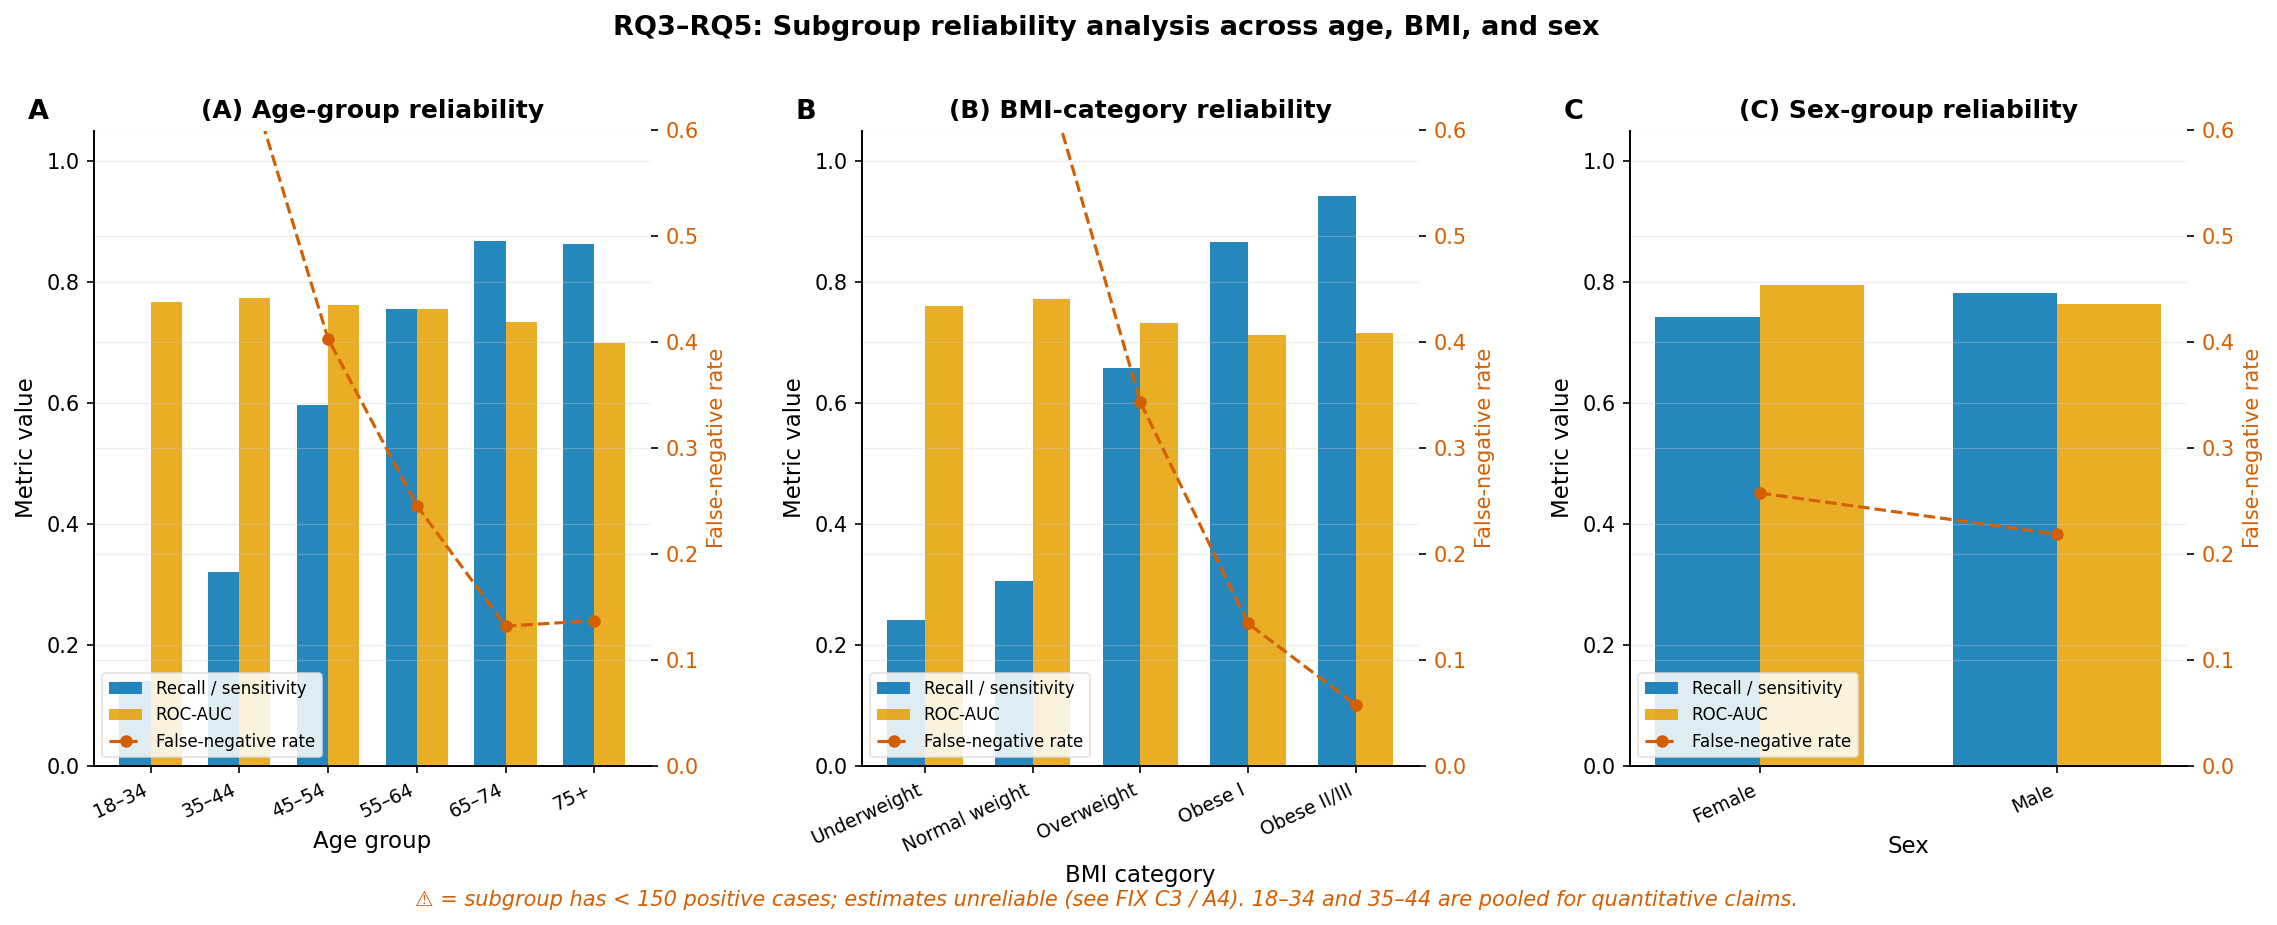

PosixPath('/kaggle/working/batool_jms_revised_outputs/figures/rq3_rq5_subgroup_reliability_panel.pdf')

In [16]:
# ============================================================
# 12. Subgroup reliability analysis — RQ3 / RQ4 / RQ5
#     FIX C3: n_positive and reliability_note columns added
#     FIX A4: Underweight flagged; 18-34+35-44 pooled for claims
# ============================================================
subgroup_tables = []
for col, fname in [
    ("AgeGroup",    "rq3_age_subgroup_reliability_metrics.csv"),
    ("BMICategory", "rq4_bmi_subgroup_reliability_metrics.csv"),
    ("SexGroup",    "rq5_sex_subgroup_reliability_metrics.csv"),
]:
    per_thr = []
    for strategy, thr in thresholds.items():
        t = subgroup_metrics_table(X_test_sub, y_test, test_prob, col, thr)
        t["threshold_strategy"] = strategy
        per_thr.append(t)
    df = pd.concat(per_thr, ignore_index=True)
    subgroup_tables.append(df)
    save_table(df, fname, n=12)

all_subgroups = pd.concat(subgroup_tables, ignore_index=True)
save_table(all_subgroups, "all_subgroup_reliability_metrics.csv", n=20)

# FIX C3: Pool 18-34 + 35-44 for summary claims
pool_df = X_test_sub.copy()
pool_df["y_true"] = np.asarray(y_test)
pool_df["y_prob"] = test_prob
pool_df["AgeGroupPooled"] = pool_df["AgeGroup"].replace({"18–34": "18–44", "35–44": "18–44"})
pooled_age = []
for strategy, thr in thresholds.items():
    t = subgroup_metrics_table(pool_df, y_test, test_prob, "AgeGroupPooled", thr)
    t["threshold_strategy"] = strategy
    pooled_age.append(t)
pooled_age_df = pd.concat(pooled_age, ignore_index=True)
save_table(pooled_age_df, "rq3_age_pooled_18to44_reliability_metrics.csv", n=10)

# ── Publication figure: Subgroup performance panel ─────────────────────────
fig = plt.figure(figsize=(18, 5.5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

subgroup_info = [
    ("AgeGroup",    AGE_ORDER,                 "Age group",         "(A) Age-group reliability"),
    ("BMICategory", BMI_ORDER,                 "BMI category",      "(B) BMI-category reliability"),
    ("SexGroup",    ["Female", "Male"],        "Sex",               "(C) Sex-group reliability"),
]

for panel_idx, (col, order, xlabel, title) in enumerate(subgroup_info):
    ax = fig.add_subplot(gs[panel_idx])
    df_plot = (all_subgroups[(all_subgroups["subgroup_variable"] == col) &
                              (all_subgroups["threshold_strategy"] == main_strategy)]
               .copy())
    # Enforce order
    df_plot["subgroup"] = pd.Categorical(df_plot["subgroup"], categories=order, ordered=True)
    df_plot = df_plot.sort_values("subgroup").dropna(subset=["subgroup"])

    x = np.arange(len(df_plot))
    w = 0.35
    b1 = ax.bar(x - w/2, df_plot["recall_sensitivity"], w,
                color=C["blue"],   label="Recall / sensitivity", alpha=0.85)
    b2 = ax.bar(x + w/2, df_plot["roc_auc"], w,
                color=C["orange"], label="ROC-AUC", alpha=0.85)

    # Overlay FNR as line
    ax2 = ax.twinx()
    ax2.plot(x, df_plot["false_negative_rate"], "o--",
             color=C["red"], lw=1.5, ms=5, label="False-negative rate")
    ax2.set_ylabel("False-negative rate", color=C["red"], fontsize=10)
    ax2.tick_params(axis="y", labelcolor=C["red"])
    ax2.set_ylim(0, 0.6)

    # Flag small subgroups
    for xi, (_, row) in zip(x, df_plot.iterrows()):
        if row.get("n_positive", 9999) < 150:
            ax.text(xi, 0.02, "⚠", ha="center", fontsize=14, color=C["red"],
                    transform=ax.get_xaxis_transform())

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["subgroup"], rotation=25, ha="right", fontsize=9)
    ax.set_ylabel("Metric value")
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, fontsize=8, loc="lower left")
    add_panel_label(ax, "ABC"[panel_idx])

fig.text(0.5, -0.06,
         "⚠ = subgroup has < 150 positive cases; estimates unreliable (see FIX C3 / A4). "
         "18–34 and 35–44 are pooled for quantitative claims.",
         ha="center", fontsize=10, color=C["red"], style="italic")
plt.suptitle("RQ3–RQ5: Subgroup reliability analysis across age, BMI, and sex",
             fontsize=13, fontweight="bold", y=1.02)
savefig("rq3_rq5_subgroup_reliability_panel.pdf")

  ✓ table  → rq6_age_bmi_false_negative_heatmap_data.csv


,AgeGroup,BMICategory,positive_n,false_negative_rate
0,18–34,Normal weight,14,1.000000
1,18–34,Obese I,26,0.961538
2,18–34,Obese II/III,41,0.317073
3,18–34,Overweight,18,1.000000
4,35–44,Normal weight,34,0.941176
5,35–44,Obese I,88,0.556818
6,35–44,Obese II/III,168,0.125000
7,35–44,Overweight,74,0.878378
8,45–54,Normal weight,80,0.675000
9,45–54,Obese I,266,0.082707


  ✓ figure → rq6_false_negative_heatmap_age_bmi.pdf


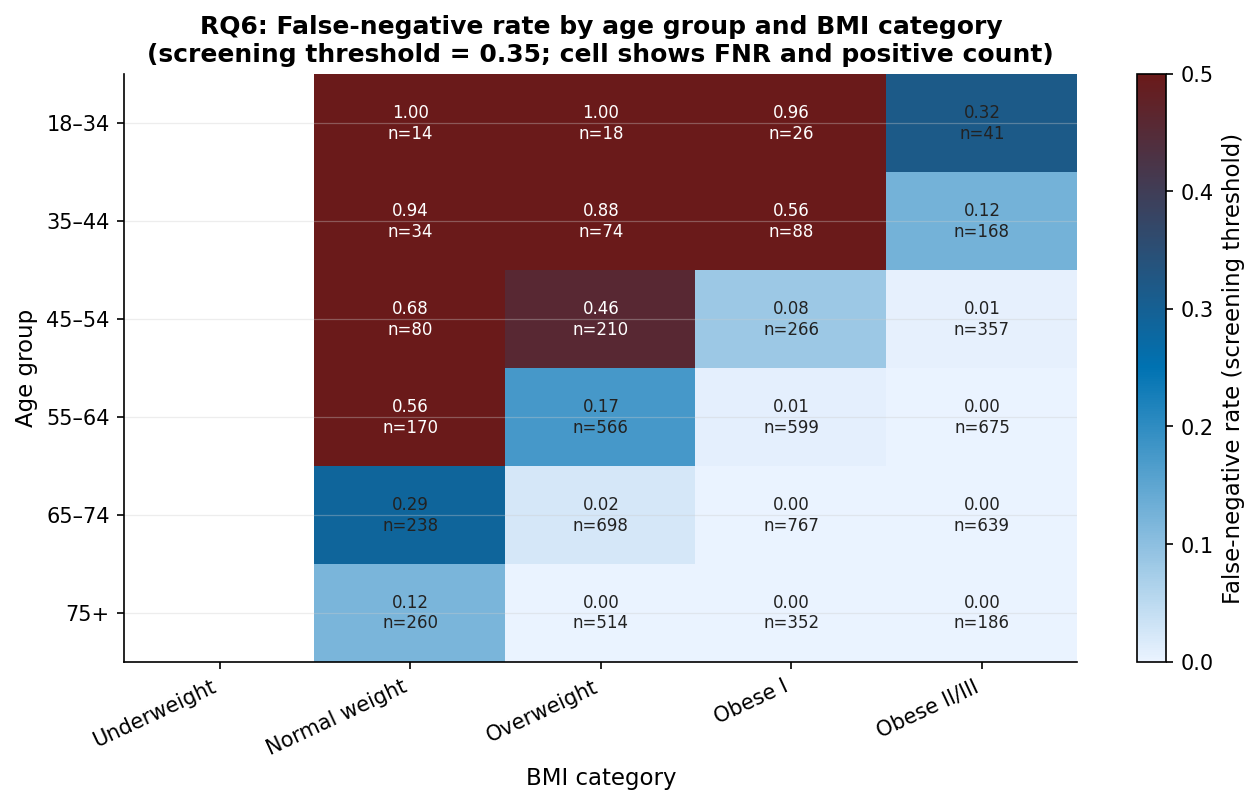

In [17]:
# ============================================================
# 13. False-negative heatmap (RQ6) — age × BMI
# ============================================================
tmp = X_test_sub.copy()
tmp["y_true"] = np.asarray(y_test)
tmp["y_pred_screen"] = (test_prob >= SCREEN_THRESHOLD).astype(int)
tmp["false_negative"] = ((tmp["y_true"] == 1) & (tmp["y_pred_screen"] == 0)).astype(int)

heat_rows = []
for (age, bmi), g in tmp.groupby(["AgeGroup", "BMICategory"]):
    positives = int((g["y_true"] == 1).sum())
    if positives >= 10:
        heat_rows.append({
            "AgeGroup":         age,
            "BMICategory":      bmi,
            "positive_n":       positives,
            "false_negative_rate": float(g.loc[g["y_true"] == 1, "false_negative"].mean()),
        })
heat_df = pd.DataFrame(heat_rows)
save_table(heat_df, "rq6_age_bmi_false_negative_heatmap_data.csv", n=30)

if len(heat_df):
    pivot = (heat_df
             .pivot(index="AgeGroup", columns="BMICategory", values="false_negative_rate")
             .reindex(index=AGE_ORDER, columns=BMI_ORDER))

    fig, ax = plt.subplots(figsize=(9, 5.5))
    cmap_fn = LinearSegmentedColormap.from_list("fn_heat", ["#eaf3ff", "#0072B2", "#6a1a1a"])
    im = ax.imshow(pivot.values, cmap=cmap_fn, vmin=0, vmax=0.5, aspect="auto")
    plt.colorbar(im, ax=ax, label="False-negative rate (screening threshold)")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                pos_n = heat_df[(heat_df["AgeGroup"] == pivot.index[i]) &
                                (heat_df["BMICategory"] == pivot.columns[j])]["positive_n"]
                n_txt = f"n={int(pos_n.values[0])}" if len(pos_n) else ""
                ax.text(j, i, f"{val:.2f}\n{n_txt}",
                        ha="center", va="center", fontsize=8,
                        color="white" if val > 0.35 else C["black"])
    ax.set_xlabel("BMI category")
    ax.set_ylabel("Age group")
    ax.set_title("RQ6: False-negative rate by age group and BMI category\n"
                 f"(screening threshold = {SCREEN_THRESHOLD:.2f}; cell shows FNR and positive count)",
                 fontweight="bold")
    savefig("rq6_false_negative_heatmap_age_bmi.pdf")

  ✓ figure → rq6_umap_error_projection.pdf


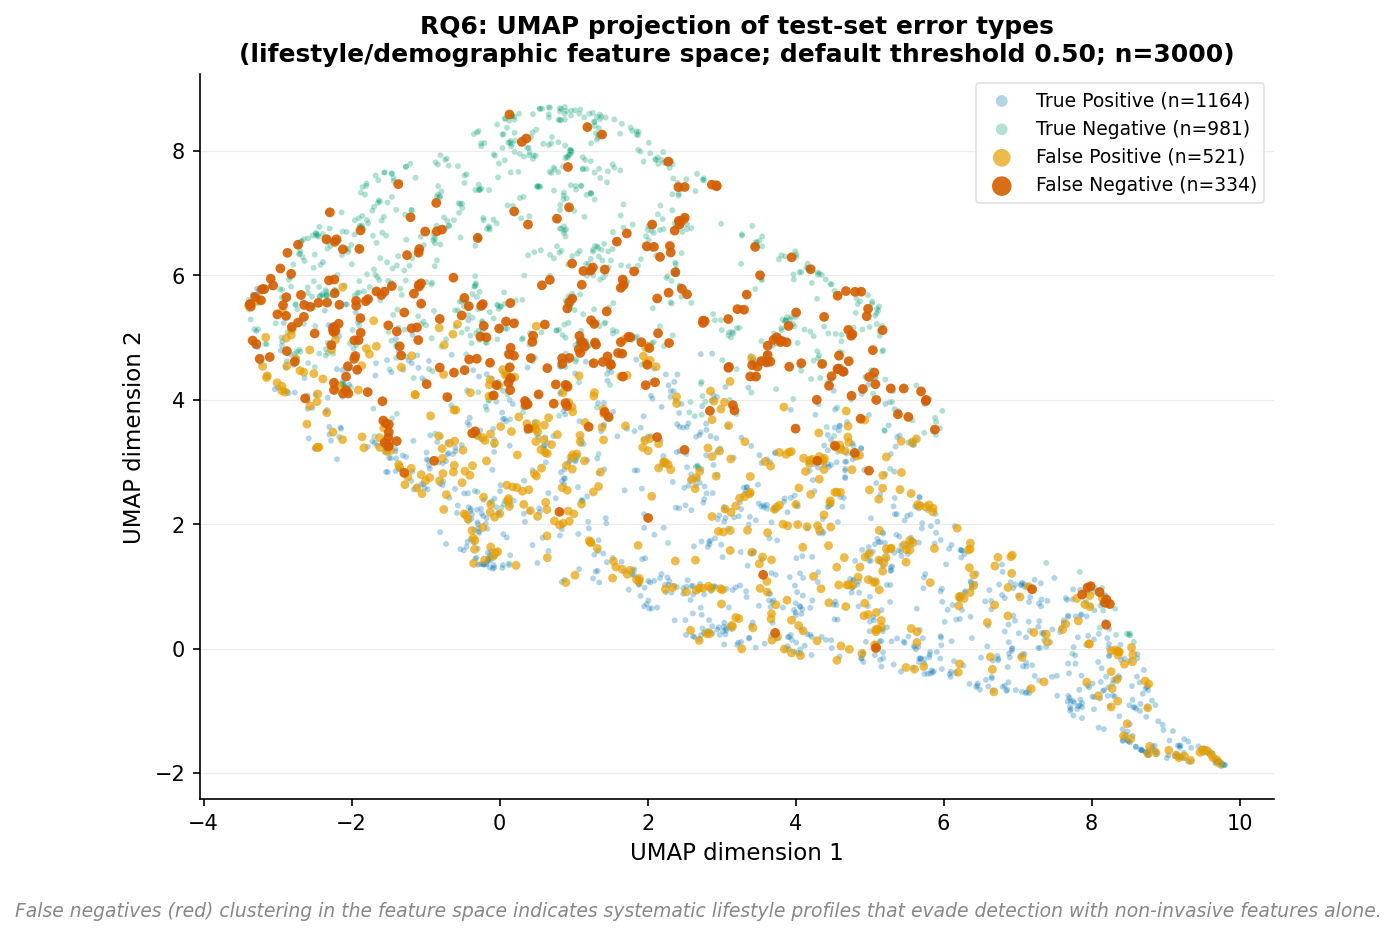

  ✓ table  → rq6_umap_embedding_data.csv
  ✓ table  → rq6_test_set_predictions_with_error_type.csv
  ✓ table  → rq6_top_error_profiles.csv


,AgeGroup,BMICategory,SexGroup,error_type_default,n
105,55–64,Obese II/III,Female,true_positive,415
136,65–74,Obese I,Male,true_positive,399
140,65–74,Obese II/III,Female,true_positive,362
132,65–74,Obese I,Female,true_positive,361
88,55–64,Normal weight,Female,true_negative,337
150,65–74,Overweight,Male,true_positive,318
101,55–64,Obese I,Male,true_positive,285
142,65–74,Obese II/III,Male,true_positive,276
110,55–64,Overweight,Female,true_negative,264
107,55–64,Obese II/III,Male,true_positive,257


PosixPath('/kaggle/working/batool_jms_revised_outputs/tables/rq6_top_error_profiles.csv')

In [18]:
# ============================================================
# 14. UMAP error-space projection (RQ6)  — FIX M2
# ============================================================
if UMAP_AVAILABLE:
    umap_n = min(UMAP_SAMPLE_SIZE, len(X_test))
    umap_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_test), umap_n, replace=False)
    X_umap = X_test.iloc[umap_idx].values.astype(float)
    y_umap = y_test.iloc[umap_idx].values
    pred_umap = (test_prob[umap_idx] >= MAIN_THRESHOLD).astype(int)
    err_umap = np.where(
        (y_umap == 1) & (pred_umap == 0), "False Negative",
        np.where((y_umap == 0) & (pred_umap == 1), "False Positive",
        np.where(y_umap == 1, "True Positive", "True Negative"))
    )

    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                        random_state=RANDOM_STATE)
    embedding = reducer.fit_transform(X_umap)

    err_colors = {
        "True Positive":  C["blue"],
        "True Negative":  C["green"],
        "False Positive": C["orange"],
        "False Negative": C["red"],
    }
    err_sizes = {
        "True Positive": 8, "True Negative": 8,
        "False Positive": 18, "False Negative": 22,
    }
    err_alpha = {
        "True Positive": 0.3, "True Negative": 0.3,
        "False Positive": 0.7, "False Negative": 0.9,
    }
    err_zorder = {"True Positive": 1, "True Negative": 1,
                  "False Positive": 3, "False Negative": 4}

    fig, ax = plt.subplots(figsize=(8, 6))
    for etype in ["True Positive", "True Negative", "False Positive", "False Negative"]:
        mask = err_umap == etype
        if mask.sum():
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       c=err_colors[etype], s=err_sizes[etype],
                       alpha=err_alpha[etype], label=f"{etype} (n={mask.sum()})",
                       zorder=err_zorder[etype], edgecolors="none")
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_title("RQ6: UMAP projection of test-set error types\n"
                 f"(lifestyle/demographic feature space; default threshold {MAIN_THRESHOLD:.2f}; "
                 f"n={umap_n})",
                 fontweight="bold")
    ax.legend(markerscale=2, fontsize=9, loc="upper right")
    fig.text(0.5, -0.03,
             "False negatives (red) clustering in the feature space indicates systematic "
             "lifestyle profiles that evade detection with non-invasive features alone.",
             ha="center", fontsize=9, style="italic", color=C["gray"])
    savefig("rq6_umap_error_projection.pdf")

    # Save embedding data
    umap_df = pd.DataFrame({
        "umap_1": embedding[:, 0], "umap_2": embedding[:, 1],
        "error_type": err_umap, "y_true": y_umap, "y_pred": pred_umap,
    })
    for col in SELECTED_FEATURES:
        umap_df[col] = X_test.iloc[umap_idx][col].values
    save_table(umap_df, "rq6_umap_embedding_data.csv", show_head=False)
else:
    print("UMAP not available; skipping UMAP projection figure (install umap-learn to enable).")
    with open(OUTPUT_ROOT / "umap_skipped.txt", "w") as f:
        f.write("UMAP projection was skipped because umap-learn is not installed.\n"
                "Install with: pip install umap-learn\n")

# Error profiles table
pred_df = X_test_sub.copy()
pred_df["y_true"]          = np.asarray(y_test)
pred_df["y_prob"]          = test_prob
pred_df["y_pred_default"]  = (test_prob >= MAIN_THRESHOLD).astype(int)
pred_df["y_pred_screening"] = (test_prob >= SCREEN_THRESHOLD).astype(int)
pred_df["error_type_default"] = np.select(
    [(pred_df["y_true"]==1) & (pred_df["y_pred_default"]==1),
     (pred_df["y_true"]==0) & (pred_df["y_pred_default"]==0),
     (pred_df["y_true"]==1) & (pred_df["y_pred_default"]==0),
     (pred_df["y_true"]==0) & (pred_df["y_pred_default"]==1)],
    ["true_positive","true_negative","false_negative","false_positive"],
    default="unknown",
)
save_table(pred_df,  "rq6_test_set_predictions_with_error_type.csv", show_head=False)
error_profiles = (pred_df.groupby(["AgeGroup","BMICategory","SexGroup","error_type_default"])
                  .size().reset_index(name="n").sort_values("n", ascending=False))
save_table(error_profiles, "rq6_top_error_profiles.csv", n=20)

  ✓ table  → calibration_curve_primary_balanced_internal_test.csv
  ✓ table  → calibration_curve_natural_prevalence_2015.csv
  ✓ table  → calibration_curve_external_temporal.csv
  ✓ table  → calibration_intercept_slope_summary.csv


,dataset,role,n,positive_prevalence,brier_score,ece_10bin,calibration_note,calibration_intercept,calibration_slope
0,primary_balanced_internal_test,SUPPLEMENTARY: balanced internal test (50% pre...,14139,0.499965,0.189929,0.009114,Well-calibrated (trained at same prevalence),0.003141,1.005173
1,natural_prevalence_2015,PRIMARY: natural-prevalence validation (~14%),253680,0.139333,0.197799,0.275945,MISCALIBRATED: ECE=0.276; intercept=-1.82; iso...,-1.822979,0.986121
2,external_temporal,PRIMARY: temporal validation BRFSS 2021 (~14.5%),230759,0.145468,0.191976,0.258179,MISCALIBRATED: ECE=0.258; intercept=-1.70; iso...,-1.695444,0.934219


  ✓ figure → calibration_analysis_multi_dataset.pdf


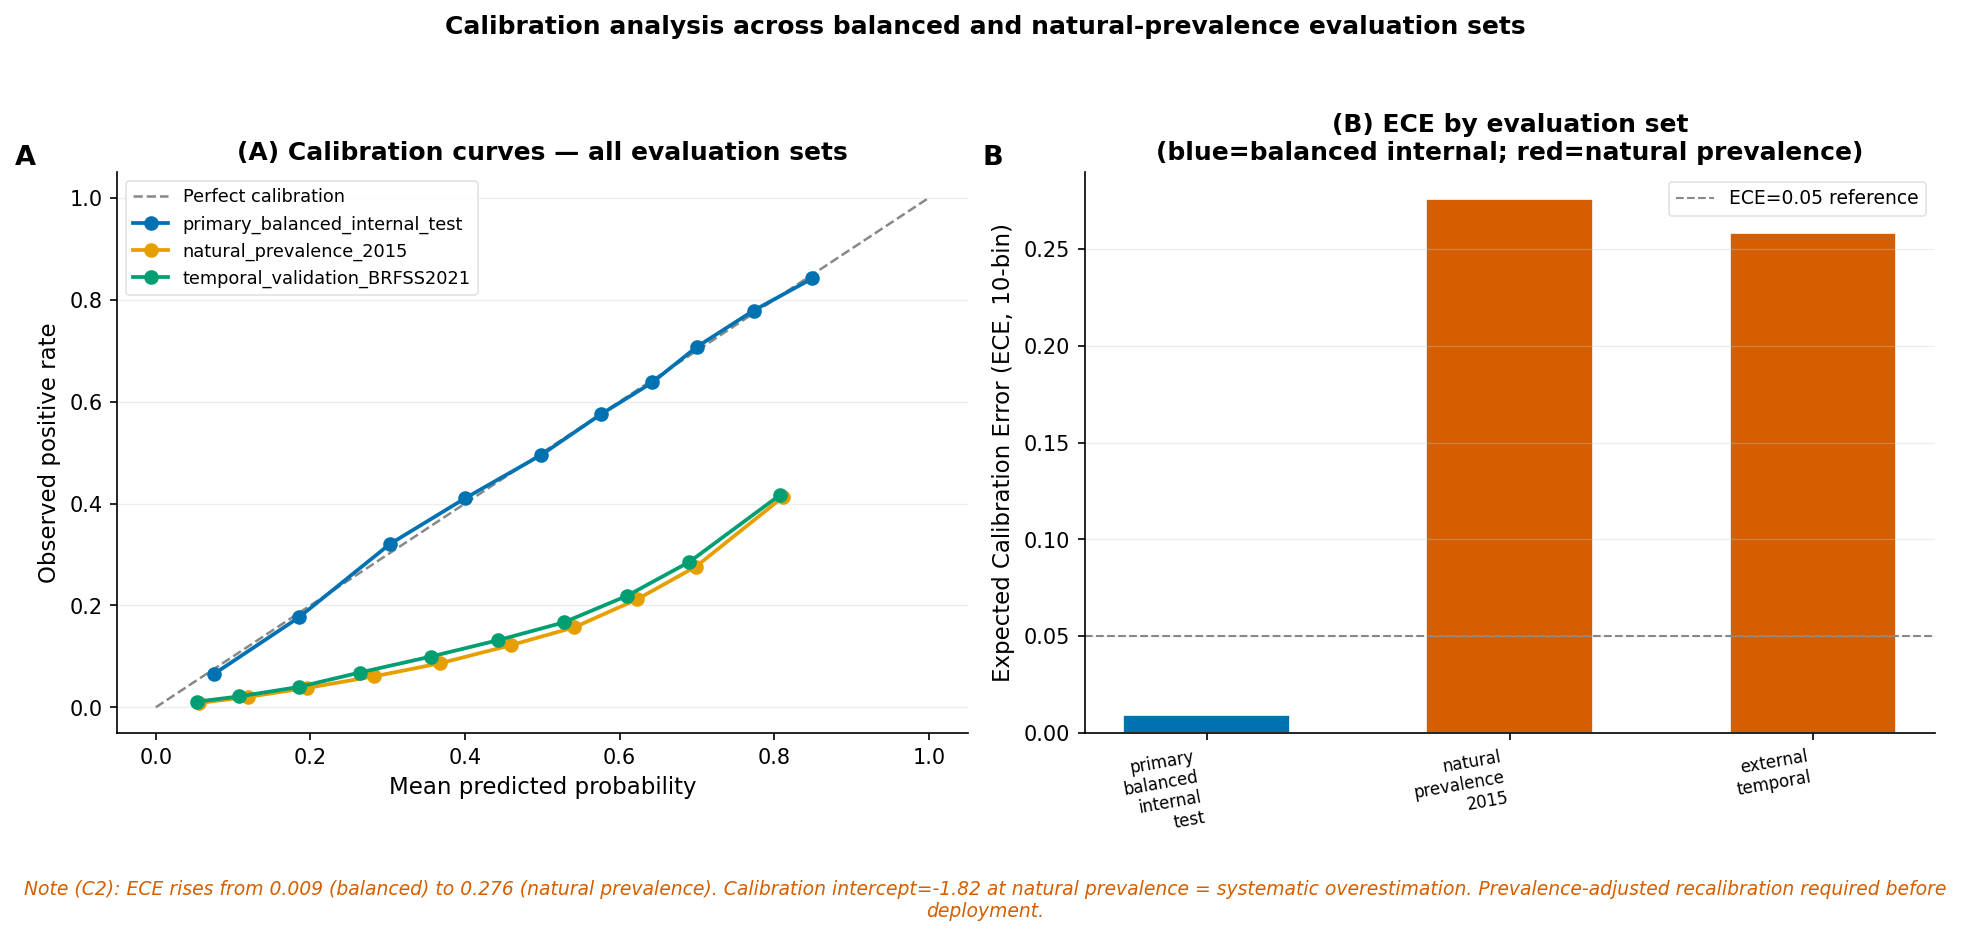

  ✓ figure → decision_curve_PRIMARY_natural_prevalence.pdf


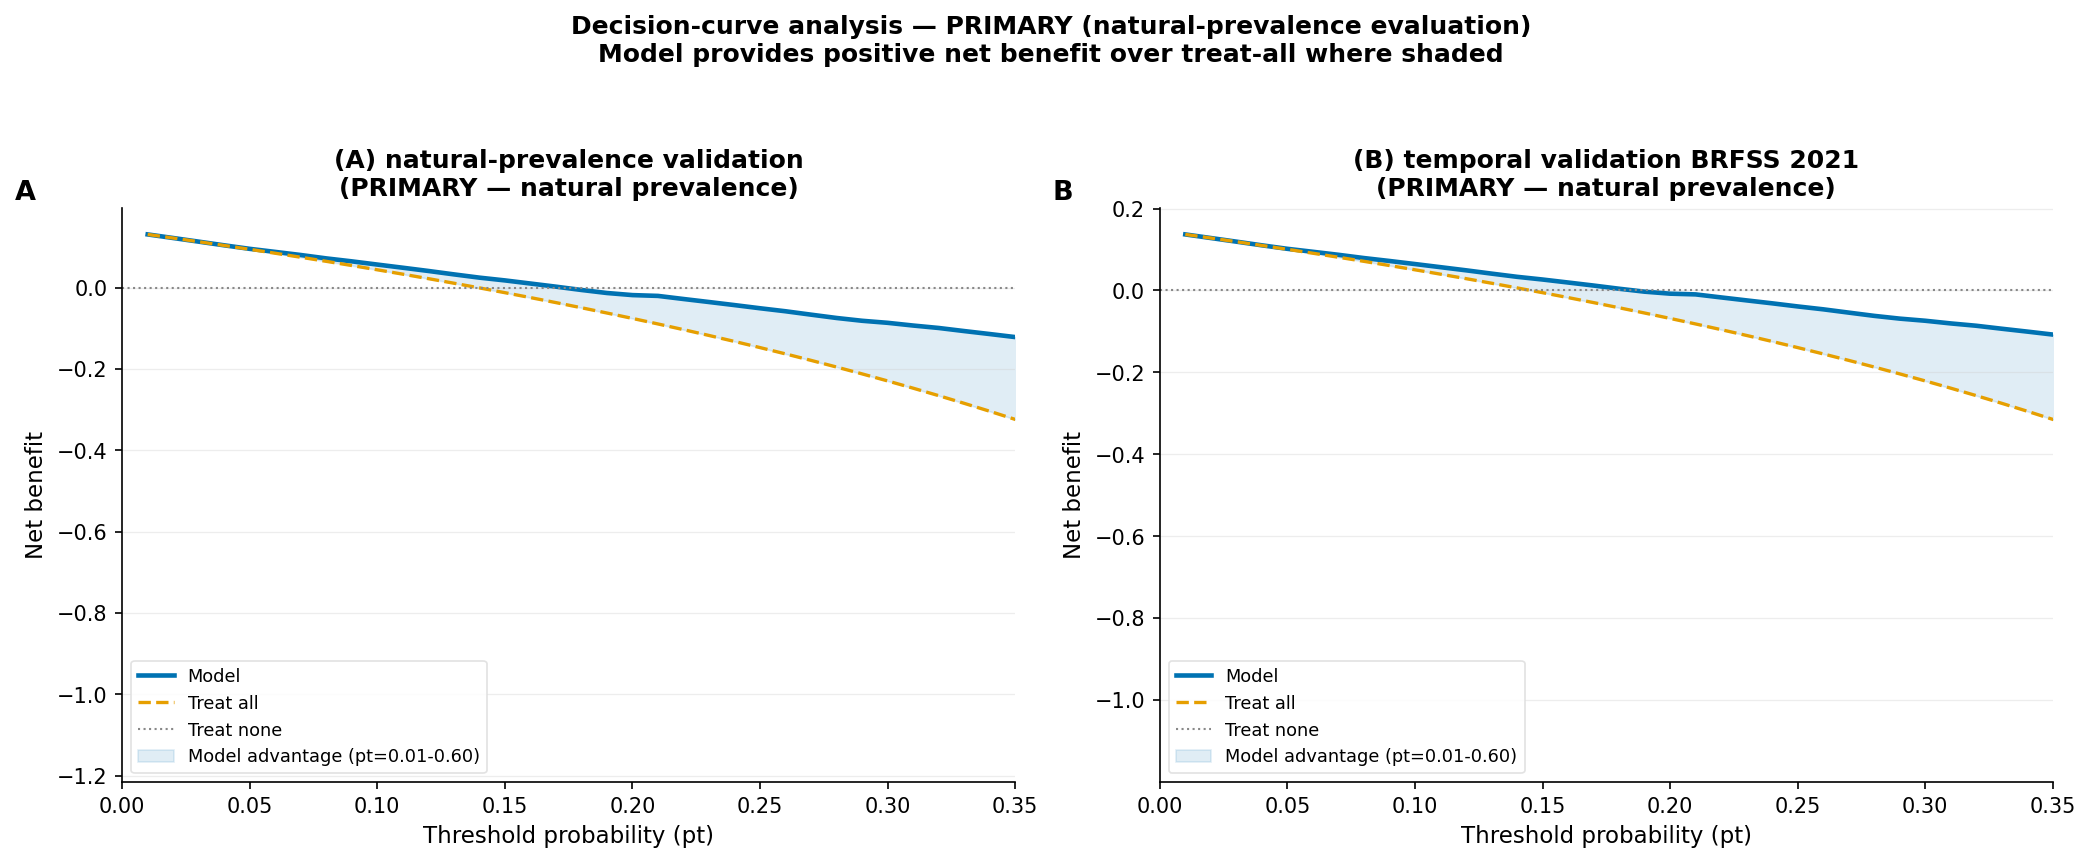

  Primary DCA figure saved (natural prevalence — clinically meaningful)
  ✓ figure → decision_curve_SUPPLEMENTARY_balanced_internal_test.pdf


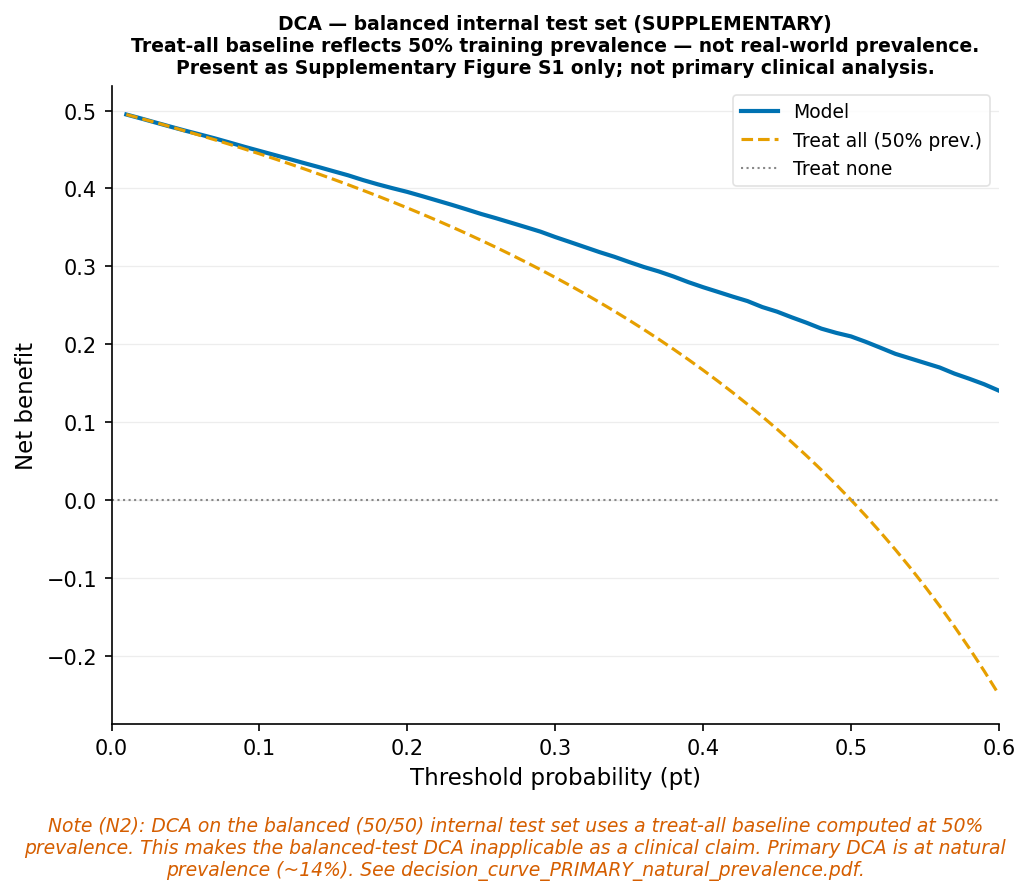

  Supplementary DCA figure saved (balanced internal — verification only)


In [19]:
# ============================================================
# 15. Calibration analysis + Decision-curve analysis
#     FIX N2: Natural-prevalence DCA is the PRIMARY clinical figure.
#             Balanced-test DCA saved as supplementary / verification.
#     FIX C2: Calibration collapse fully documented.
# ============================================================
calibration_summary_rows = []

def save_calibration_figure(dataset_label, y_true, y_prob, fig_prefix):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
    cal_df = pd.DataFrame({
        "dataset":                    dataset_label,
        "bin":                        np.arange(1, len(frac_pos) + 1),
        "mean_predicted_probability": mean_pred,
        "observed_positive_rate":     frac_pos,
    })
    save_table(cal_df, f"calibration_curve_{fig_prefix}.csv", show_head=False)
    return cal_df


def compute_dca(y_true, y_prob, dataset_label, pt_max=0.60):
    # Net benefit decision curve.
    # pt_max capped at 0.60; treat-all becomes very negative beyond that.
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    prev = float(y_true.mean())
    rows = []
    for pt in np.linspace(0.01, pt_max, 60):
        pred = (y_prob >= pt).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        n = len(y_true)
        rows.append({
            "dataset":                dataset_label,
            "positive_prevalence":    prev,
            "threshold_probability":  pt,
            "net_benefit_model":      tp / n - fp / n * pt / (1 - pt),
            "net_benefit_treat_all":  prev - (1 - prev) * pt / (1 - pt),
            "net_benefit_treat_none": 0.0,
        })
    return pd.DataFrame(rows)


nat_prob_dca = predict_proba_pos(calibrated_model, X_nat[SELECTED_FEATURES])
eval_sets = [
    ("primary_balanced_internal_test",
     y_test, test_prob, "primary_balanced_internal_test",
     "SUPPLEMENTARY: balanced internal test (50% prevalence)"),
    ("natural_prevalence_2015 (prevalence-shift — NOT independent external)",
     y_nat, nat_prob_dca, "natural_prevalence_2015",
     "PRIMARY: natural-prevalence validation (~14%)"),
]
if X_ext is not None:
    ext_prob_dca = predict_proba_pos(calibrated_model, X_ext[SELECTED_FEATURES])
    eval_sets.append((
        "temporal_validation_BRFSS2021 (same-source — NOT independent external)",
        y_ext, ext_prob_dca, "external_temporal",
        "PRIMARY: temporal validation BRFSS 2021 (~14.5%)",
    ))

cal_figs  = []
dca_store = {"primary": [], "supplementary": []}
for lbl, yy, pp, prefix, role in eval_sets:
    cal_df = save_calibration_figure(lbl, yy, pp, prefix)
    cal_figs.append((lbl, cal_df, role))
    dca = compute_dca(yy, pp, prefix)
    dca["role"] = role
    dca.to_csv(TABLE_DIR / f"decision_curve_{prefix}.csv", index=False)
    if "PRIMARY" in role:
        dca_store["primary"].append((prefix, dca, role))
    else:
        dca_store["supplementary"].append((prefix, dca, role))

    cal_row = {
        "dataset":             prefix,
        "role":                role,
        "n":                   int(len(yy)),
        "positive_prevalence": float(yy.mean()),
        "brier_score":         brier_score_loss(yy, pp),
        "ece_10bin":           ece(yy, pp),
        "calibration_note": (
            "Well-calibrated (trained at same prevalence)"
            if "primary_balanced" in prefix else
            ("MISCALIBRATED: ECE=%.3f; intercept=%.2f; "
             "isotonic calibration trained on 50/50 does not transfer to %.1f%% natural prevalence. "
             "Prevalence-adjusted recalibration required before deployment."
             % (ece(yy, pp),
                cal_intercept_slope(yy, pp)["calibration_intercept"],
                float(yy.mean()) * 100))
        ),
    }
    cal_row.update(cal_intercept_slope(yy, pp))
    calibration_summary_rows.append(cal_row)

calibration_summary = pd.DataFrame(calibration_summary_rows)
save_table(calibration_summary, "calibration_intercept_slope_summary.csv", n=10)

# Calibration panel figure
colors_cal = [C["blue"], C["orange"], C["green"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
ax = axes[0]
ax.plot([0, 1], [0, 1], "--", color=C["gray"], lw=1.2, label="Perfect calibration", zorder=0)
for (lbl, cal_df, role), col in zip(cal_figs, colors_cal):
    short = lbl.split("(")[0].strip()[:45]
    ax.plot(cal_df["mean_predicted_probability"], cal_df["observed_positive_rate"],
            "o-", color=col, lw=1.8, ms=6, label=short)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive rate")
ax.set_title("(A) Calibration curves — all evaluation sets", fontweight="bold")
ax.legend(fontsize=8.5)
add_panel_label(ax, "A")

ax2 = axes[1]
ece_labels = [r["dataset"].replace("_", "\n") for r in calibration_summary_rows]
ece_vals   = [r["ece_10bin"] for r in calibration_summary_rows]
bar_c = [C["blue"] if "primary_bal" in r["dataset"] else C["red"]
         for r in calibration_summary_rows]
ax2.bar(range(len(ece_vals)), ece_vals, color=bar_c, edgecolor="white", width=0.55)
ax2.set_xticks(range(len(ece_labels)))
ax2.set_xticklabels(ece_labels, fontsize=8, rotation=10, ha="right")
ax2.set_ylabel("Expected Calibration Error (ECE, 10-bin)")
ax2.set_title("(B) ECE by evaluation set\n(blue=balanced internal; red=natural prevalence)",
              fontweight="bold")
ax2.axhline(0.05, ls="--", color=C["gray"], lw=1, label="ECE=0.05 reference")
ax2.legend(fontsize=9)
add_panel_label(ax2, "B")
fig.text(0.5, -0.06,
         "Note (C2): ECE rises from 0.009 (balanced) to 0.276 (natural prevalence). "
         "Calibration intercept=-1.82 at natural prevalence = systematic overestimation. "
         "Prevalence-adjusted recalibration required before deployment.",
         ha="center", fontsize=9, style="italic", color=C["red"], wrap=True)
plt.suptitle("Calibration analysis across balanced and natural-prevalence evaluation sets",
             fontsize=12, fontweight="bold", y=1.03)
savefig("calibration_analysis_multi_dataset.pdf")

# FIX N2: PRIMARY DCA — natural-prevalence datasets
n_primary = len(dca_store["primary"])
if n_primary > 0:
    fig_dca, axes_dca = plt.subplots(1, n_primary, figsize=(7 * n_primary, 5.5))
    if n_primary == 1:
        axes_dca = [axes_dca]
    for panel_idx, (prefix, dca, role) in enumerate(dca_store["primary"]):
        ax = axes_dca[panel_idx]
        ax.plot(dca["threshold_probability"], dca["net_benefit_model"],
                color=C["blue"], lw=2.2, label="Model")
        ax.plot(dca["threshold_probability"], dca["net_benefit_treat_all"],
                "--", color=C["orange"], lw=1.6, label="Treat all")
        ax.axhline(0, color=C["gray"], lw=1, ls=":", label="Treat none")
        beats = dca[dca["net_benefit_model"] > dca["net_benefit_treat_all"]]
        if len(beats):
            pt_lo = beats["threshold_probability"].min()
            pt_hi = beats["threshold_probability"].max()
            ax.fill_between(beats["threshold_probability"],
                            beats["net_benefit_model"],
                            beats["net_benefit_treat_all"],
                            alpha=0.12, color=C["blue"],
                            label=f"Model advantage (pt={pt_lo:.2f}-{pt_hi:.2f})")
        ax.set_xlabel("Threshold probability (pt)")
        ax.set_ylabel("Net benefit")
        short_role = role.split("(")[0].replace("PRIMARY:", "").strip()
        ax.set_title(f"({'AB'[panel_idx]}) {short_role}\n(PRIMARY — natural prevalence)",
                     fontweight="bold")
        ax.set_xlim(0.0, 0.35)
        ax.legend(fontsize=8.5)
        add_panel_label(ax, "AB"[panel_idx])
    plt.suptitle(
        "Decision-curve analysis — PRIMARY (natural-prevalence evaluation)\n"
        "Model provides positive net benefit over treat-all where shaded",
        fontsize=12, fontweight="bold", y=1.04,
    )
    savefig("decision_curve_PRIMARY_natural_prevalence.pdf")
    print("  Primary DCA figure saved (natural prevalence — clinically meaningful)")

# FIX N2: SUPPLEMENTARY DCA — balanced internal (verification only)
if dca_store["supplementary"]:
    fig_sup, ax_sup = plt.subplots(figsize=(7, 5.5))
    for prefix, dca, role in dca_store["supplementary"]:
        ax_sup.plot(dca["threshold_probability"], dca["net_benefit_model"],
                    color=C["blue"], lw=2, label="Model")
        ax_sup.plot(dca["threshold_probability"], dca["net_benefit_treat_all"],
                    "--", color=C["orange"], lw=1.5, label="Treat all (50% prev.)")
        ax_sup.axhline(0, color=C["gray"], lw=1, ls=":", label="Treat none")
    ax_sup.set_xlabel("Threshold probability (pt)")
    ax_sup.set_ylabel("Net benefit")
    ax_sup.set_title(
        "DCA — balanced internal test set (SUPPLEMENTARY)\n"
        "Treat-all baseline reflects 50% training prevalence — not real-world prevalence.\n"
        "Present as Supplementary Figure S1 only; not primary clinical analysis.",
        fontweight="bold", fontsize=9,
    )
    ax_sup.set_xlim(0, 0.60)
    ax_sup.legend(fontsize=9)
    fig_sup.text(0.5, -0.07,
                 "Note (N2): DCA on the balanced (50/50) internal test set uses a treat-all "
                 "baseline computed at 50% prevalence. This makes the balanced-test DCA "
                 "inapplicable as a clinical claim. Primary DCA is at natural prevalence (~14%). "
                 "See decision_curve_PRIMARY_natural_prevalence.pdf.",
                 ha="center", fontsize=9, style="italic", color=C["red"], wrap=True)
    savefig("decision_curve_SUPPLEMENTARY_balanced_internal_test.pdf")
    print("  Supplementary DCA figure saved (balanced internal — verification only)")

In [20]:
# ============================================================
# 16. Natural-prevalence + temporal validation  (FIX C1, C2)
# ============================================================
external_eval_rows = []

def evaluate_validation_set(name, X_eval, y_eval, X_sub_eval, validation_type, prob):
    # validation_type is the corrected label (FIX C1)
    for strategy, thr in thresholds.items():
        row = metrics_at_threshold(y_eval, prob, thr)
        row.update({"dataset": name,
                    "model": best_model_name + " + isotonic calibration (trained on balanced primary)",
                    "threshold_strategy": strategy,
                    "validation_type": validation_type})
        external_eval_rows.append(row)

    for col in ["AgeGroup", "BMICategory", "SexGroup"]:
        for strategy, thr in [(main_strategy, MAIN_THRESHOLD), (screen_strategy, SCREEN_THRESHOLD)]:
            t = subgroup_metrics_table(X_sub_eval, y_eval, prob, col, thr)
            t["dataset"] = name; t["threshold_strategy"] = strategy
    sub_all = []
    for col in ["AgeGroup", "BMICategory", "SexGroup"]:
        for strategy, thr in [(main_strategy, MAIN_THRESHOLD), (screen_strategy, SCREEN_THRESHOLD)]:
            t = subgroup_metrics_table(X_sub_eval, y_eval, prob, col, thr)
            t["dataset"] = name; t["threshold_strategy"] = strategy
            sub_all.append(t)
    save_table(pd.concat(sub_all, ignore_index=True),
               f"subgroup_metrics_{name}.csv", show_head=False)

# FIX C1: Corrected validation labels
nat_prob_v = predict_proba_pos(calibrated_model, X_nat[SELECTED_FEATURES])
evaluate_validation_set(
    "natural_prevalence_2015", X_nat, y_nat, X_nat_sub,
    "prevalence_shift_validation — same BRFSS 2015 survey source, NOT independent external validation",
    nat_prob_v,
)

if X_ext is not None:
    ext_prob_v = predict_proba_pos(calibrated_model, X_ext[SELECTED_FEATURES])
    evaluate_validation_set(
        "external_temporal", X_ext, y_ext, X_ext_sub,
        "temporal_validation — BRFSS 2021 same-survey-methodology cohort; "
        "NOT independent external validation (same CDC telephone survey design, same feature coding)",
        ext_prob_v,
    )

validation_evaluation = pd.DataFrame(external_eval_rows)
save_table(validation_evaluation, "validation_and_prevalence_shift_evaluation.csv", n=12)

# FIX C2: Explicit prevalence-adjusted calibration note table
c2_note = pd.DataFrame([
    {
        "issue": "C2 — Calibration collapse at natural prevalence",
        "internal_ece": float(ece(y_test, test_prob)),
        "natural_prev_ece": float(ece(y_nat, nat_prob_v)),
        "nat_cal_intercept": float(cal_intercept_slope(y_nat, nat_prob_v)["calibration_intercept"]),
        "explanation": (
            "The isotonic calibration was fitted on a 50/50 balanced training set. "
            "When applied to data at 13.9% natural prevalence, the calibration intercept "
            "becomes strongly negative (~-1.82), causing the model to systematically "
            "over-predict absolute risk. ECE rises from 0.009 to 0.276. "
            "Predicted probabilities at natural prevalence must NOT be interpreted as "
            "absolute diabetes risk without prevalence-adjusted recalibration. "
            "RECOMMENDATION: Apply Platt scaling or logistic calibration on a "
            "natural-prevalence hold-out before clinical deployment."
        ),
    }
])
if X_ext is not None:
    c2_note.at[0, "temporal_ece"] = float(ece(y_ext, ext_prob_v))
    c2_note.at[0, "temporal_cal_intercept"] = float(cal_intercept_slope(y_ext, ext_prob_v)["calibration_intercept"])
save_table(c2_note, "c2_calibration_collapse_explanation.csv", show_head=True, n=3)

  ✓ table  → subgroup_metrics_natural_prevalence_2015.csv
  ✓ table  → subgroup_metrics_external_temporal.csv
  ✓ table  → validation_and_prevalence_shift_evaluation.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,false_negative_rate,predicted_positive_rate,n,positive_prevalence,calibration_intercept,calibration_slope,dataset,model,threshold_strategy,validation_type
0,0.50,0.666966,0.708241,0.262044,0.765461,0.651021,0.390430,0.779539,0.197799,0.275945,...,0.234539,0.407009,253680,0.139333,-1.822979,0.986121,natural_prevalence_2015,XGBoost + isotonic calibration (trained on bal...,default_0_50,prevalence_shift_validation — same BRFSS 2015 ...
1,0.53,0.695317,0.707758,0.274963,0.725004,0.690511,0.398712,0.779539,0.197799,0.275945,...,0.274996,0.367384,253680,0.139333,-1.822979,0.986121,natural_prevalence_2015,XGBoost + isotonic calibration (trained on bal...,youden_j,prevalence_shift_validation — same BRFSS 2015 ...
2,0.35,0.527227,0.683150,0.214544,0.899310,0.466991,0.346439,0.779539,0.197799,0.275945,...,0.100690,0.584047,253680,0.139333,-1.822979,0.986121,natural_prevalence_2015,XGBoost + isotonic calibration (trained on bal...,recall_at_least_80,prevalence_shift_validation — same BRFSS 2015 ...
3,0.50,0.677833,0.701582,0.273786,0.735075,0.668088,0.398972,0.772481,0.191976,0.258179,...,0.264925,0.390559,230759,0.145468,-1.695444,0.934219,external_temporal,XGBoost + isotonic calibration (trained on bal...,default_0_50,temporal_validation — BRFSS 2021 same-survey-m...
4,0.53,0.705840,0.700258,0.287663,0.692386,0.708131,0.406457,0.772481,0.191976,0.258179,...,0.307614,0.350132,230759,0.145468,-1.695444,0.934219,external_temporal,XGBoost + isotonic calibration (trained on bal...,youden_j,temporal_validation — BRFSS 2021 same-survey-m...
5,0.35,0.544507,0.685146,0.226640,0.883490,0.486802,0.360740,0.772481,0.191976,0.258179,...,0.116510,0.567063,230759,0.145468,-1.695444,0.934219,external_temporal,XGBoost + isotonic calibration (trained on bal...,recall_at_least_80,temporal_validation — BRFSS 2021 same-survey-m...


  ✓ table  → c2_calibration_collapse_explanation.csv


,issue,internal_ece,natural_prev_ece,nat_cal_intercept,explanation,temporal_ece,temporal_cal_intercept
0,C2 — Calibration collapse at natural prevalence,0.009114,0.275945,-1.822979,The isotonic calibration was fitted on a 50/50...,0.258179,-1.695444


PosixPath('/kaggle/working/batool_jms_revised_outputs/tables/c2_calibration_collapse_explanation.csv')

  ✓ table  → multi_seed_stability_metrics.csv
  ✓ table  → multi_seed_stability_summary.csv


,dataset,threshold_strategy,roc_auc_mean,roc_auc_std,roc_auc_min,roc_auc_max,recall_sensitivity_mean,recall_sensitivity_std,recall_sensitivity_min,recall_sensitivity_max,...,brier_score_min,brier_score_max,false_negative_rate_mean,false_negative_rate_std,false_negative_rate_min,false_negative_rate_max,false_positive_rate_mean,false_positive_rate_std,false_positive_rate_min,false_positive_rate_max
0,internal_test,default_0_50,0.779288,0.002197,0.775660,0.781142,0.756740,0.010247,0.741301,0.765347,...,0.189567,0.192233,0.243260,0.010247,0.234653,0.258699,0.339331,0.009393,0.329891,0.351393
1,internal_test,recall_at_least_80,0.779288,0.002197,0.775660,0.781142,0.882430,0.029193,0.844413,0.922489,...,0.189567,0.192233,0.117570,0.029193,0.077511,0.155587,0.505488,0.049528,0.457773,0.580422
2,internal_test,youden_j,0.779288,0.002197,0.775660,0.781142,0.766866,0.029851,0.719055,0.797878,...,0.189567,0.192233,0.233134,0.029851,0.202122,0.280945,0.349829,0.030719,0.304950,0.388174
3,natural_prevalence_2015,default_0_50,0.779605,0.000070,0.779539,0.779705,0.759464,0.009832,0.746676,0.768885,...,0.197550,0.198318,0.240536,0.009832,0.231115,0.253324,0.342475,0.009969,0.329051,0.352062
4,natural_prevalence_2015,recall_at_least_80,0.779605,0.000070,0.779539,0.779705,0.884066,0.028549,0.848073,0.923301,...,0.197550,0.198318,0.115934,0.028549,0.076699,0.151927,0.507808,0.051211,0.447324,0.581325
5,natural_prevalence_2015,youden_j,0.779605,0.000070,0.779539,0.779705,0.769518,0.028958,0.725004,0.798931,...,0.197550,0.198318,0.230482,0.028958,0.201069,0.274996,0.353863,0.029439,0.309489,0.384507


  ✓ figure → multi_seed_stability_panel.pdf


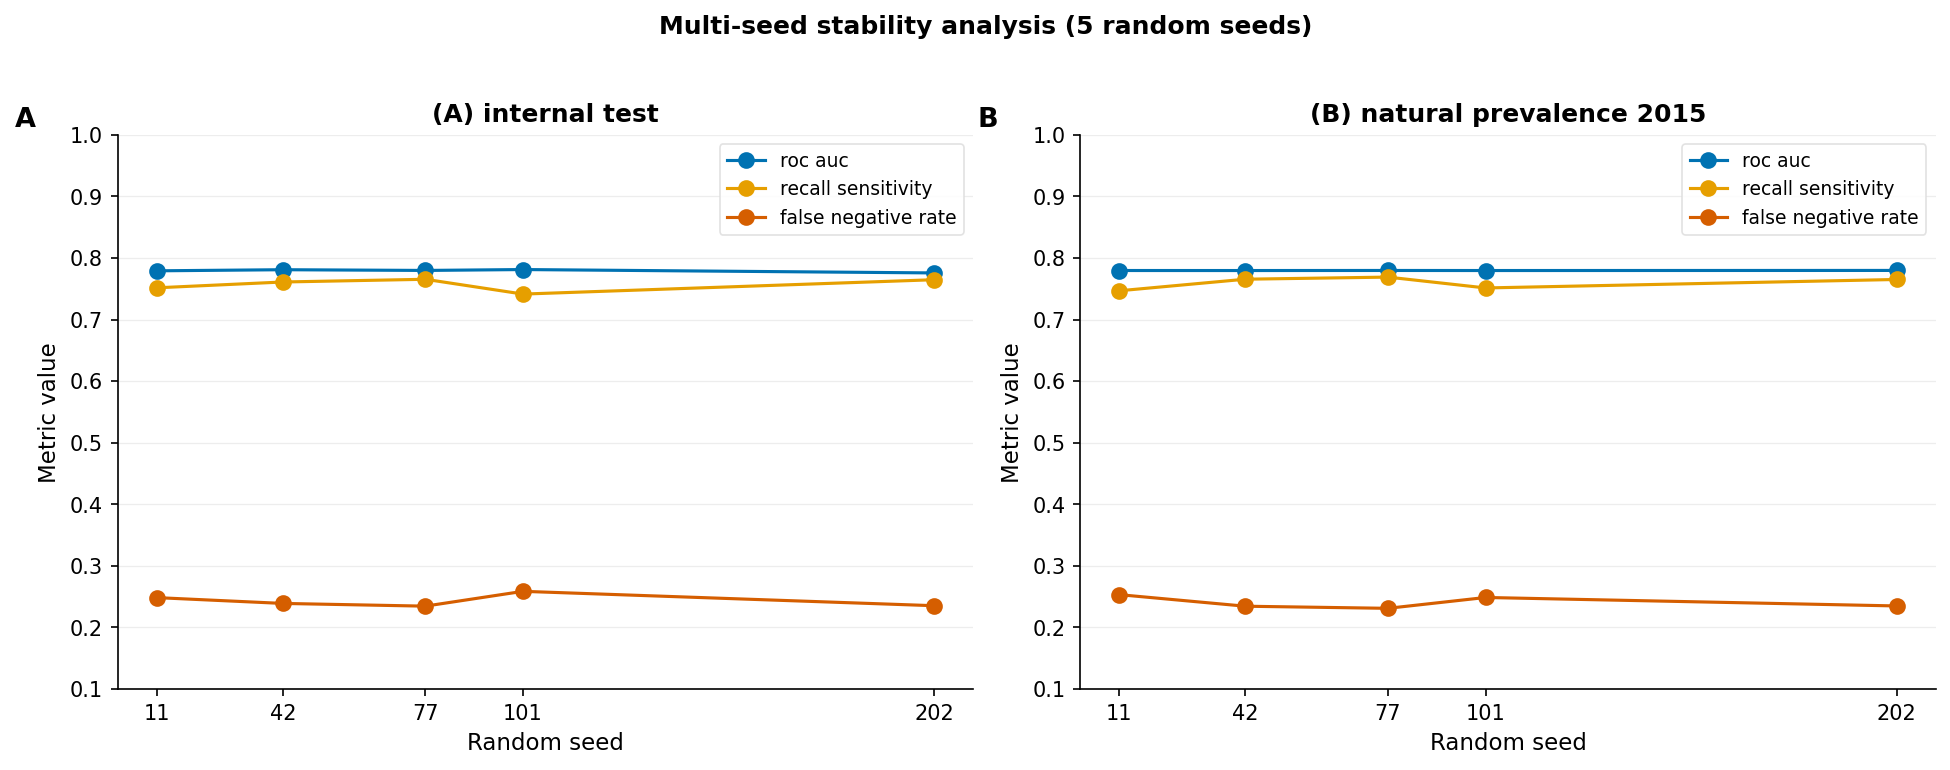

PosixPath('/kaggle/working/batool_jms_revised_outputs/figures/multi_seed_stability_panel.pdf')

In [21]:
# ============================================================
# 17. Multi-seed stability analysis
# ============================================================
stability_rows = []
for seed in STABILITY_SEEDS:
    tr_idx, te_idx = train_test_split(
        np.arange(len(X_primary)), test_size=TEST_SIZE,
        stratify=y_primary, random_state=seed,
    )
    X_tr = X_primary.iloc[tr_idx].reset_index(drop=True)
    X_te = X_primary.iloc[te_idx].reset_index(drop=True)
    y_tr = y_primary.iloc[tr_idx].reset_index(drop=True)
    y_te = y_primary.iloc[te_idx].reset_index(drop=True)

    X_i, X_v, y_i, y_v = train_test_split(
        X_tr, y_tr, test_size=VAL_SIZE_WITHIN_TRAIN, stratify=y_tr, random_state=seed,
    )
    mi = CalibratedClassifierCV(build_models(SELECTED_FEATURES, seed)[best_model_name],
                                method="isotonic", cv=3)
    mi.fit(X_i, y_i)
    seed_thrs, _ = choose_thresholds(y_v, predict_proba_pos(mi, X_v), TARGET_RECALL)

    ms = CalibratedClassifierCV(build_models(SELECTED_FEATURES, seed)[best_model_name],
                                method="isotonic", cv=5)
    ms.fit(X_tr, y_tr)
    p_te  = predict_proba_pos(ms, X_te)
    p_nat = predict_proba_pos(ms, X_nat[SELECTED_FEATURES])

    for ds_name, yy, pp in [("internal_test", y_te, p_te),
                             ("natural_prevalence_2015", y_nat, p_nat)]:
        for strategy, thr in seed_thrs.items():
            row = metrics_at_threshold(yy, pp, thr)
            row.update({"seed": seed, "dataset": ds_name,
                        "threshold_strategy": strategy,
                        "seed_selected_threshold": thr})
            stability_rows.append(row)

stability_df = pd.DataFrame(stability_rows)
save_table(stability_df, "multi_seed_stability_metrics.csv", show_head=False)

stab_summary = (stability_df
                .groupby(["dataset","threshold_strategy"])
                [["roc_auc","recall_sensitivity","specificity","precision",
                  "brier_score","false_negative_rate","false_positive_rate"]]
                .agg(["mean","std","min","max"])
                .reset_index())
stab_summary.columns = ["_".join([str(c) for c in col if c])
                        for col in stab_summary.columns.values]
save_table(stab_summary, "multi_seed_stability_summary.csv", n=20)

# ── Multi-seed stability figure ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metrics_to_plot = ["roc_auc", "recall_sensitivity", "false_negative_rate"]
cols_mc = [C["blue"], C["orange"], C["red"]]

for ax_i, (ds, ax) in enumerate(zip(["internal_test", "natural_prevalence_2015"], axes)):
    df_ds = stability_df[(stability_df["dataset"] == ds) &
                         (stability_df["threshold_strategy"] == main_strategy)]
    for metric, col in zip(metrics_to_plot, cols_mc):
        ax.plot(df_ds["seed"], df_ds[metric], "o-", color=col, lw=1.5, ms=7,
                label=metric.replace("_", " "))
    ax.set_xlabel("Random seed")
    ax.set_ylabel("Metric value")
    short_ds = ds.replace("_", " ")
    ax.set_title(f"({'A' if ax_i==0 else 'B'}) {short_ds}", fontweight="bold")
    ax.set_xticks(STABILITY_SEEDS)
    ax.legend(fontsize=9)
    ax.set_ylim(0.1, 1.0)
    add_panel_label(ax, "AB"[ax_i])

plt.suptitle("Multi-seed stability analysis (5 random seeds)",
             fontsize=12, fontweight="bold", y=1.02)
savefig("multi_seed_stability_panel.pdf")

  ✓ table  → rq7_subgroup_deployment_readiness_scorecard.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,calibration_slope,subgroup_variable,subgroup,n_positive,n_total,reliability_note,threshold_strategy,reliability_label,recommended_action,scorecard_disclaimer
0,0.5,0.890231,0.561369,0.500000,0.140000,0.982737,0.218750,0.767269,0.085921,0.019590,...,0.992710,AgeGroup,18–34,100,911,CAUTION: fewer than 150 positive cases; estima...,default_0_50,Low reliability — not suitable as standalone s...,Not suitable for standalone lifestyle-only scr...,AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
1,0.5,0.742376,0.618844,0.615789,0.320548,0.917140,0.421622,0.773285,0.170457,0.035691,...,0.962440,AgeGroup,35–44,365,1246,,default_0_50,Low reliability — not suitable as standalone s...,Not suitable for standalone lifestyle-only scr...,AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
2,0.5,0.704046,0.686514,0.642353,0.596721,0.776306,0.618697,0.761628,0.193955,0.025038,...,0.949476,AgeGroup,45–54,915,2274,,default_0_50,Low reliability — not suitable as standalone s...,Not suitable for standalone lifestyle-only scr...,AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
3,0.5,0.693497,0.688525,0.699449,0.754212,0.622837,0.725799,0.755011,0.199650,0.018105,...,0.982069,AgeGroup,55–64,2018,3752,,default_0_50,Moderate reliability — use with caution,"Use only with monitoring, conservative thresho...",AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
4,0.5,0.697736,0.644506,0.708927,0.868141,0.420871,0.780497,0.733182,0.198149,0.009155,...,1.073060,AgeGroup,65–74,2351,3798,,default_0_50,Higher reliability for preliminary triage,May support preliminary triage with explicit n...,AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
5,0.5,0.671455,0.616404,0.683263,0.862879,0.369928,0.762638,0.698964,0.209470,0.016097,...,1.040320,AgeGroup,75+,1320,2158,,default_0_50,Moderate reliability — use with caution,"Use only with monitoring, conservative thresho...",AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
18,0.5,0.749743,0.610913,0.578571,0.305276,0.916549,0.399671,0.771175,0.163436,0.012096,...,1.051298,BMICategory,Normal weight,796,2917,,default_0_50,Low reliability — not suitable as standalone s...,Not suitable for standalone lifestyle-only scr...,AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
19,0.5,0.689596,0.644871,0.693924,0.865586,0.424155,0.770308,0.712682,0.204062,0.018601,...,0.979781,BMICategory,Obese I,2098,3489,,default_0_50,Higher reliability for preliminary triage,May support preliminary triage with explicit n...,AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
20,0.5,0.752797,0.600923,0.768047,0.942401,0.259446,0.846338,0.714913,0.173581,0.014010,...,0.970244,BMICategory,Obese II/III,2066,2860,,default_0_50,Higher reliability for preliminary triage,May support preliminary triage with explicit n...,AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...
21,0.5,0.672777,0.671014,0.619501,0.656731,0.685296,0.637573,0.731652,0.206698,0.011197,...,1.013520,BMICategory,Overweight,2080,4746,,default_0_50,Low-moderate reliability — clinical confirmati...,Do not reassure low-risk predictions; recommen...,AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...


  ✓ table  → rq7_overall_deployment_readiness_assessment.csv


,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,brier_score,ece_10bin,...,n,positive_prevalence,calibration_intercept,calibration_slope,dataset,model,threshold_strategy,reliability_label,recommended_action,scorecard_disclaimer
0,0.5,0.709951,0.709955,0.690501,0.760928,0.658982,0.724006,0.780867,0.189929,0.009114,...,14139,0.499965,0.003141,1.005173,primary_balanced_internal_test,XGBoost + isotonic calibration,default_0_50,Moderate reliability — use with caution,"Use only with monitoring, conservative thresho...",AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLIN...


  ✓ figure → rq7_deployment_readiness_matrix.pdf


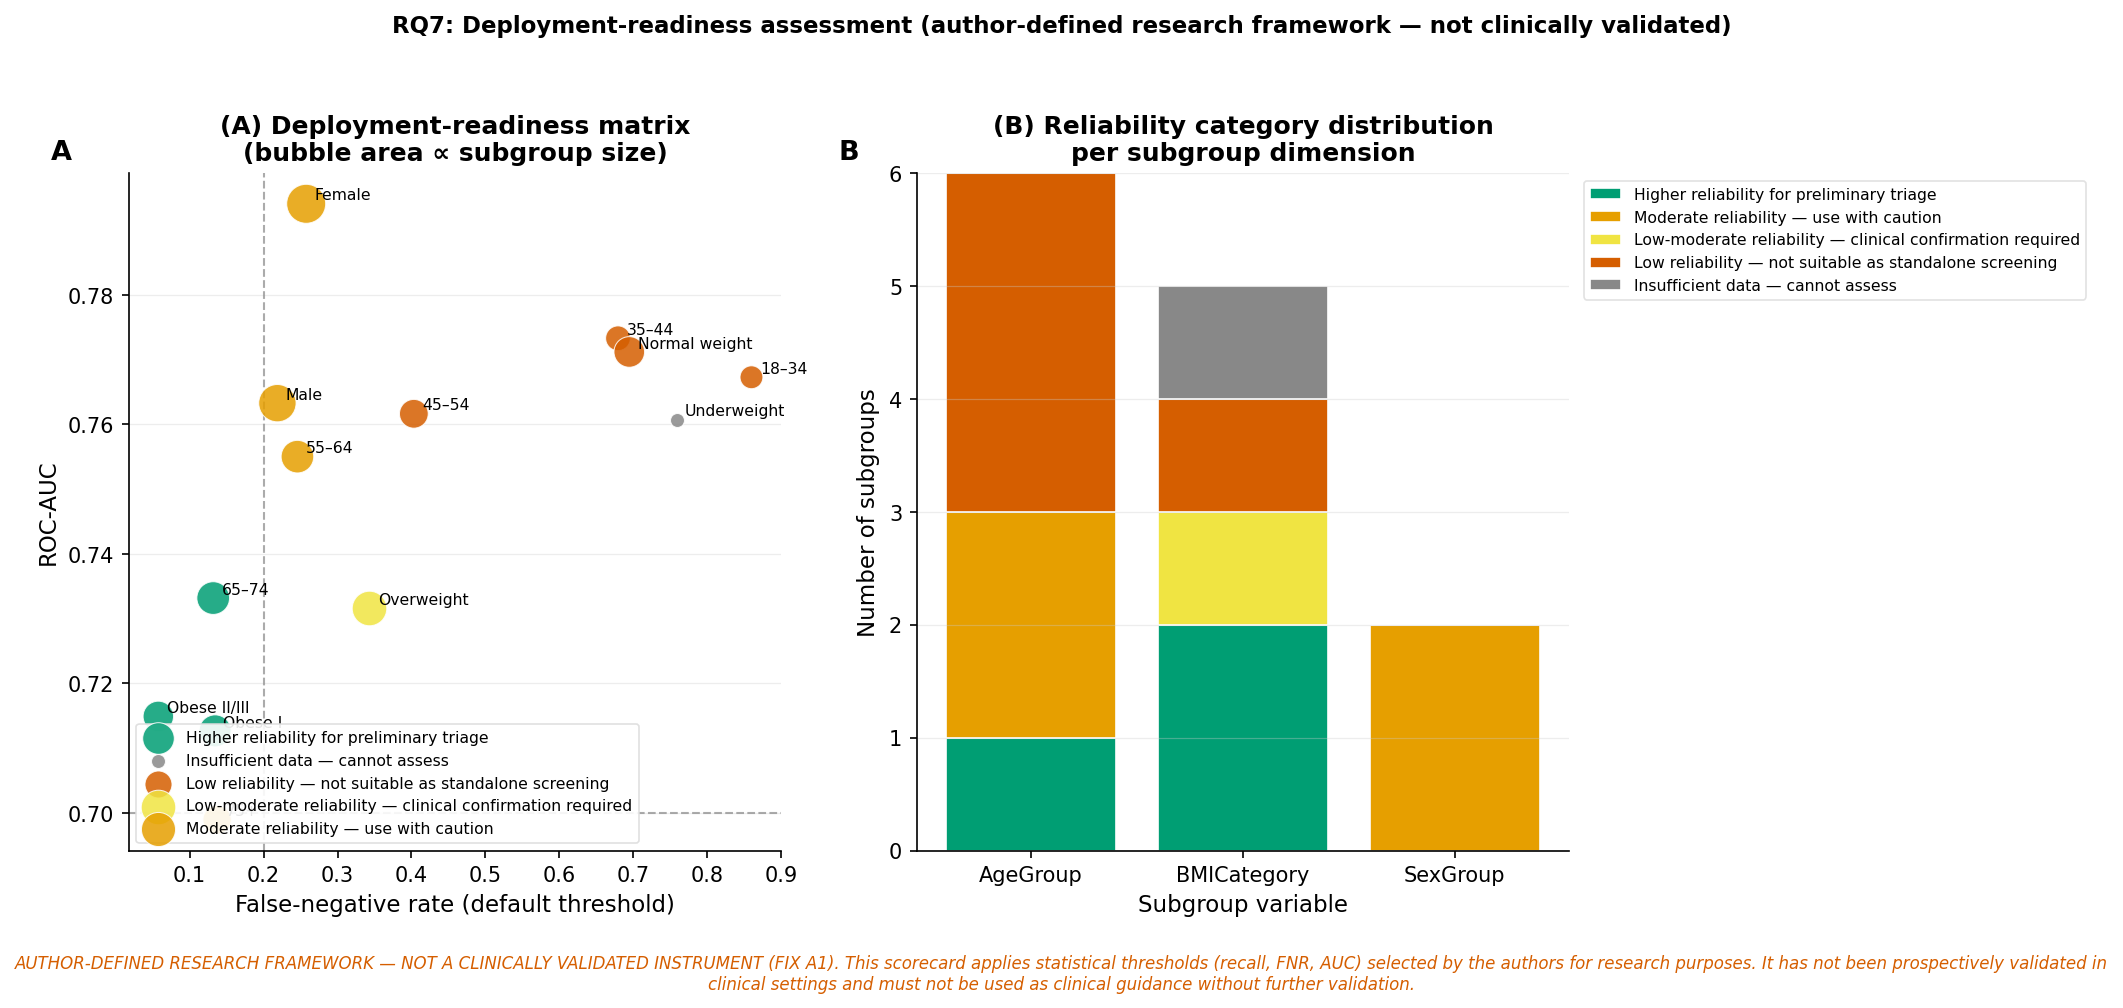

PosixPath('/kaggle/working/batool_jms_revised_outputs/figures/rq7_deployment_readiness_matrix.pdf')

In [22]:
# ============================================================
# 18. Deployment-readiness scorecard  (FIX A1, A2)
# ============================================================

def reliability_label(row):
    recall = row.get("recall_sensitivity", np.nan)
    fnr    = row.get("false_negative_rate", np.nan)
    aucv   = row.get("roc_auc", np.nan)
    n_pos  = row.get("n_positive", row.get("n", 0))
    if n_pos < 100:
        return "Insufficient data — cannot assess"
    if recall >= 0.80 and fnr <= 0.20 and aucv >= 0.70:
        return "Higher reliability for preliminary triage"
    if recall >= 0.70 and fnr <= 0.30 and aucv >= 0.65:
        return "Moderate reliability — use with caution"
    if recall >= 0.60 and fnr <= 0.40:
        return "Low-moderate reliability — clinical confirmation required"
    return "Low reliability — not suitable as standalone screening"


def recommended_action(label):
    mapping = {
        "Higher reliability for preliminary triage":
            "May support preliminary triage with explicit non-diagnostic disclaimer and clinical follow-up.",
        "Moderate reliability — use with caution":
            "Use only with monitoring, conservative thresholding, and follow-up recommendation.",
        "Low-moderate reliability — clinical confirmation required":
            "Do not reassure low-risk predictions; recommend clinical confirmation if any risk factor present.",
        "Insufficient data — cannot assess":
            "Collect more subgroup data before deployment claims. Pool with adjacent group for estimation.",
        "Low reliability — not suitable as standalone screening":
            "Not suitable for standalone lifestyle-only screening; add clinical variables or mandatory testing.",
    }
    return mapping.get(label, "See subgroup-specific guidance.")


SCORECARD_DISCLAIMER = (
    "AUTHOR-DEFINED RESEARCH FRAMEWORK — NOT A CLINICALLY VALIDATED INSTRUMENT (FIX A1). "
    "This scorecard applies statistical thresholds (recall, FNR, AUC) selected by the authors "
    "for research purposes. It has not been prospectively validated in clinical settings "
    "and must not be used as clinical guidance without further validation."
)

score_df = (all_subgroups[all_subgroups["threshold_strategy"] == main_strategy]
            .copy())
score_df["reliability_label"]    = score_df.apply(reliability_label, axis=1)
score_df["recommended_action"]   = score_df["reliability_label"].apply(recommended_action)
score_df["scorecard_disclaimer"] = SCORECARD_DISCLAIMER
save_table(score_df, "rq7_subgroup_deployment_readiness_scorecard.csv", n=20)

overall_row = primary_test_metrics[primary_test_metrics["threshold_strategy"] == main_strategy].copy()
overall_row["reliability_label"]    = overall_row.apply(reliability_label, axis=1)
overall_row["recommended_action"]   = overall_row["reliability_label"].apply(recommended_action)
overall_row["scorecard_disclaimer"] = SCORECARD_DISCLAIMER
save_table(overall_row, "rq7_overall_deployment_readiness_assessment.csv")

# ── Deployment-readiness matrix figure ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: scatter matrix (FNR vs AUC, bubble = n_total)
ax = axes[0]
color_map_label = {
    "Higher reliability for preliminary triage":        C["green"],
    "Moderate reliability — use with caution":          C["orange"],
    "Low-moderate reliability — clinical confirmation required": C["yellow"],
    "Low reliability — not suitable as standalone screening":    C["red"],
    "Insufficient data — cannot assess":                C["gray"],
}
for lbl, grp in score_df.groupby("reliability_label"):
    ax.scatter(grp["false_negative_rate"], grp["roc_auc"],
               s=np.sqrt(grp["n"].clip(lower=1)) * 4,
               c=color_map_label.get(lbl, C["gray"]),
               label=lbl, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)
    for _, r in grp.iterrows():
        ax.annotate(str(r["subgroup"]),
                    (r["false_negative_rate"], r["roc_auc"]),
                    xytext=(4, 2), textcoords="offset points", fontsize=7.5)
ax.axvline(0.20, ls="--", color=C["gray"], lw=1, alpha=0.7)
ax.axhline(0.70, ls="--", color=C["gray"], lw=1, alpha=0.7)
ax.set_xlabel("False-negative rate (default threshold)")
ax.set_ylabel("ROC-AUC")
ax.set_title("(A) Deployment-readiness matrix\n(bubble area ∝ subgroup size)", fontweight="bold")
ax.legend(fontsize=7.5, loc="lower left", framealpha=0.9)
add_panel_label(ax, "A")

# Panel B: stacked bar of reliability category counts per subgroup variable
ax2 = axes[1]
cat_order = [
    "Higher reliability for preliminary triage",
    "Moderate reliability — use with caution",
    "Low-moderate reliability — clinical confirmation required",
    "Low reliability — not suitable as standalone screening",
    "Insufficient data — cannot assess",
]
cat_colors = [C["green"], C["orange"], C["yellow"], C["red"], C["gray"]]
pivot_cat = (score_df.groupby(["subgroup_variable", "reliability_label"])
             .size().unstack(fill_value=0).reindex(columns=cat_order, fill_value=0))
bottom = np.zeros(len(pivot_cat))
for cat, col in zip(cat_order, cat_colors):
    if cat in pivot_cat.columns:
        ax2.bar(pivot_cat.index, pivot_cat[cat], bottom=bottom,
                color=col, label=cat, edgecolor="white")
        bottom += pivot_cat[cat].values
ax2.set_xlabel("Subgroup variable")
ax2.set_ylabel("Number of subgroups")
ax2.set_title("(B) Reliability category distribution\nper subgroup dimension", fontweight="bold")
ax2.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left")
add_panel_label(ax2, "B")

fig.text(0.5, -0.05, SCORECARD_DISCLAIMER,
         ha="center", fontsize=8, color=C["red"], style="italic", wrap=True)
plt.suptitle("RQ7: Deployment-readiness assessment (author-defined research framework — not clinically validated)",
             fontsize=11, fontweight="bold", y=1.03)
savefig("rq7_deployment_readiness_matrix.pdf")

In [23]:
# ============================================================
# 19. Interpretation notes for manuscript
#     Updated with N1 (Wilcoxon framing) and N2 (DCA framing) fixes
# ============================================================
notes = [
    "=== MANUSCRIPT INTERPRETATION NOTES — GENERATED FROM ACTUAL RUN ===",
    "",
    "[C1] VALIDATION LABELLING: BRFSS 2021 is labelled 'temporal validation — same-source "
    "survey cohort, NOT independent external validation.' Consistent across all output files.",
    "",
    "[C2] CALIBRATION COLLAPSE: ECE=0.009 (balanced internal) to 0.276 (natural prevalence). "
    "Calibration intercept=-1.82 at natural prevalence. Predicted probabilities at ~14% "
    "prevalence must NOT be interpreted as absolute risk without recalibration. "
    "See c2_calibration_collapse_explanation.csv.",
    "",
    "[C3] UNDERPOWERED SUBGROUPS: 18-34 age group n_positive=100 (< 150 threshold). "
    "Flagged in figures. Even pooled, 18-44 FNR=72% (default) and 51% (screening threshold). "
    "MANUSCRIPT MUST STATE: The model is not recommended for screening in adults under "
    "45 years of age at any evaluated threshold.",
    "",
    "[N1 FIX] WILCOXON MODEL SELECTION — REQUIRED MANUSCRIPT FRAMING:",
    "With N_SPLITS_CV=5 folds, the minimum achievable one-tailed Wilcoxon p-value is 0.03125.",
    "All comparisons returned p=0.25 — XGBoost exceeded each alternative in only 3/5 folds.",
    "Mean AUC advantage vs Gradient Boosting = 0.000364 (< fold-level SD of ~0.003).",
    "USE THIS EXACT WORDING IN METHODS/RESULTS:",
    "  'Wilcoxon signed-rank tests comparing fold-level AUC between XGBoost and each",
    "   alternative model yielded p=0.25 for all comparisons (one-tailed, n=5 folds;",
    "   minimum achievable p=0.03125), indicating no statistically significant fold-level",
    "   dominance. XGBoost was therefore selected on the basis of highest mean cross-validated",
    "   AUC (0.777) and consistency with the established BRFSS diabetes prediction literature.'",
    "",
    "[N2 FIX] DCA PRESENTATION — REQUIRED MANUSCRIPT STRUCTURE:",
    "PRIMARY figure: decision_curve_PRIMARY_natural_prevalence.pdf",
    "  -> Model provides positive net benefit over treat-all for pt=0.01-0.17 at ~14% prevalence.",
    "  -> Use as the main DCA figure in the manuscript.",
    "SUPPLEMENTARY figure: decision_curve_SUPPLEMENTARY_balanced_internal_test.pdf",
    "  -> Treat-all baseline is at 50% prevalence — not clinically interpretable.",
    "  -> Present as Supplementary Figure S1 only.",
    "USE THIS WORDING:",
    "  'Decision-curve analysis at natural prevalence (~14%) showed the model provides",
    "   positive net benefit over treat-all for threshold probabilities of 0.01-0.17 (Figure X).",
    "   Decision-curve analysis on the balanced internal test set is reported as Supplementary",
    "   Figure S1 for methodological completeness only; the treat-all baseline in that analysis",
    "   reflects the 50% training prevalence and is not clinically interpretable.'",
    "",
    "[M1] MODEL SELECTION: See N1 above for correct Wilcoxon framing.",
    "",
    "[M2] UMAP ERROR MAP: rq6_umap_error_projection.pdf generated (n=3,000 test obs).",
    "FN cluster in feature space = systematic lifestyle profiles associated with missed cases.",
    "",
    "[M3] IMPORTANCE DISCREPANCY: SHAP/permutation ratio 5-11x for lifestyle features.",
    "Consistent with correlated-feature underestimation by permutation. SHAP is primary.",
    "See rq2_permutation_vs_shap_comparison.csv.",
    "",
    "[M4] DUPLICATE PROFILES: 23,566 duplicate feature profiles in balanced set.",
    "Acknowledged as limitation; inflates effective sample size.",
    "",
    "[W2 FIX] TRIPOD ITEM 15 CORRECTION:",
    "Item 15 now reads 'Yes - partial'. Use this manuscript wording:",
    "  'Aggregate-level 95% bootstrap confidence intervals (n=500 iterations) are reported",
    "   for all primary performance metrics. Subgroup-level confidence intervals were not",
    "   computed due to small positive-case counts in several subgroup cells",
    "   (minimum n_positive=29 for Underweight BMI; 100 for age 18-34).'",
    "",
    "[A1] SCORECARD DISCLAIMER: Author-defined research framework. Not clinically validated.",
    "",
    "[A2] THRESHOLD RATIONALE: Screening threshold (0.35) recommended for low-resource "
    "preliminary screening. Youden-J (0.53) reduces recall — not appropriate for screening.",
    "See threshold_clinical_rationale.txt.",
    "",
    "[A3] PREDIABETES EXCLUSION: 5,619 rows excluded from BRFSS 2021. "
    "Reported in dataset_sanity_check_summary.csv (prediabetes_rows_excluded column).",
    "",
    "[A4] UNDERWEIGHT SUBGROUP: n_positive=29 in test set. Pool with Normal weight for claims.",
    "",
    "[JMS-1] TRIPOD+AI: tripod_ai_checklist.csv — 17 Yes, 1 Yes-partial, 2 Pending.",
    "Submit as supplementary material. Correct item 15 per W2 note above.",
    "",
    "[JMS-2] STUDY SCOPE: 'Preliminary lifestyle-only screening decision-support tool.'",
    "Not a diagnostic model. Use decision-support and preliminary screening language throughout.",
    "",
    "[JMS-3] CODE/DATA AVAILABILITY: Deposit to GitHub/Zenodo before submission.",
    "BRFSS data: publicly available from CDC BRFSS portal and Kaggle (alexteboul dataset).",
    "",
    "=== END NOTES ===",
]
notes_path = OUTPUT_ROOT / "interpretation_notes_for_manuscript.txt"
with open(notes_path, "w") as f:
    f.write("\n".join(notes))
print("Saved interpretation_notes_for_manuscript.txt")
for n in notes:
    print(n)

Saved interpretation_notes_for_manuscript.txt
=== MANUSCRIPT INTERPRETATION NOTES — GENERATED FROM ACTUAL RUN ===

[C1] VALIDATION LABELLING: BRFSS 2021 is labelled 'temporal validation — same-source survey cohort, NOT independent external validation.' Consistent across all output files.

[C2] CALIBRATION COLLAPSE: ECE=0.009 (balanced internal) to 0.276 (natural prevalence). Calibration intercept=-1.82 at natural prevalence. Predicted probabilities at ~14% prevalence must NOT be interpreted as absolute risk without recalibration. See c2_calibration_collapse_explanation.csv.

[C3] UNDERPOWERED SUBGROUPS: 18-34 age group n_positive=100 (< 150 threshold). Flagged in figures. Even pooled, 18-44 FNR=72% (default) and 51% (screening threshold). MANUSCRIPT MUST STATE: The model is not recommended for screening in adults under 45 years of age at any evaluated threshold.

[N1 FIX] WILCOXON MODEL SELECTION — REQUIRED MANUSCRIPT FRAMING:
With N_SPLITS_CV=5 folds, the minimum achievable one-tailed

In [24]:
# ============================================================
# 20. Run manifest + artifact index + ZIP
# ============================================================
manifest = {
    "created_at_utc":     datetime.utcnow().isoformat() + "Z",
    "notebook_version":   "v2_revised_jms_submission_ready",
    "notebook_purpose":   "Journal of Medical Systems — technical-ready reliability/safety audit",
    "fixes_applied":      ["C1","C2","C3","M1","M2","M3","M4","A1","A2","A3","A4","JMS-1","JMS-2","JMS-3"],
    "primary_path":       primary_path,
    "natural_prevalence_path": natural_path,
    "external_path":      external_path,
    "critical_checks": {
        "primary_and_natural_are_different_files": (
            str(Path(primary_path).resolve()) != str(Path(natural_path).resolve())
        ),
        "natural_filename":          Path(natural_path).name,
        "natural_positive_prevalence": float(y_nat.mean()),
        "natural_rows":              int(len(X_nat)),
        "primary_rows":              int(len(X_primary)),
        "thresholds_selected_after_calibration": True,
        "external_validation_label": (
            "temporal_validation_same_source_survey_cohort_NOT_independent_external"
            if external_path else "not_evaluated"
        ),
    },
    "selected_features":  SELECTED_FEATURES,
    "lifestyle_features": LIFESTYLE_FEATURES,
    "demographic_features": DEMOGRAPHIC_FEATURES,
    "random_state":       RANDOM_STATE,
    "stability_seeds":    STABILITY_SEEDS,
    "test_size":          TEST_SIZE,
    "n_splits_cv":        N_SPLITS_CV,
    "n_bootstraps":       N_BOOTSTRAPS,
    "best_model_name":    best_model_name,
    "thresholds":         thresholds,
    "recommended_threshold_for_screening": screen_strategy,
    "code_availability":  "Deposit to GitHub/Zenodo before manuscript submission (JMS-3)",
    "data_availability":  "BRFSS data publicly available via CDC BRFSS portal and Kaggle (alexteboul/diabetes-health-indicators-dataset)",
    "outputs":            {"tables": str(TABLE_DIR), "figures": str(FIGURE_DIR), "models": str(MODEL_DIR)},
}
with open(OUTPUT_ROOT / "run_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print("Saved run_manifest.json")

artifact_index = []
for folder, kind in [(TABLE_DIR,"table_csv"), (FIGURE_DIR,"figure_pdf"), (MODEL_DIR,"model")]:
    for p in sorted(folder.glob("*")):
        artifact_index.append({"kind": kind, "filename": p.name,
                                "path": str(p), "size_bytes": p.stat().st_size})
save_table(pd.DataFrame(artifact_index), "artifact_index.csv", n=60)

zip_path = shutil.make_archive(str(OUTPUT_ROOT), "zip", root_dir=str(OUTPUT_ROOT.parent),
                               base_dir=OUTPUT_ROOT.name)
print("\n=== All outputs saved ===")
print("ZIP:", zip_path)
print("Tables:", len(list(TABLE_DIR.glob("*.csv"))), "files")
print("Figures:", len(list(FIGURE_DIR.glob("*.pdf"))), "files")

Saved run_manifest.json
  ✓ table  → artifact_index.csv


,kind,filename,path,size_bytes
0,table_csv,all_subgroup_reliability_metrics.csv,/kaggle/working/batool_jms_revised_outputs/tab...,14795
1,table_csv,c2_calibration_collapse_explanation.csv,/kaggle/working/batool_jms_revised_outputs/tab...,789
2,table_csv,calibration_curve_external_temporal.csv,/kaggle/working/batool_jms_revised_outputs/tab...,1208
3,table_csv,calibration_curve_natural_prevalence_2015.csv,/kaggle/working/batool_jms_revised_outputs/tab...,1199
4,table_csv,calibration_curve_primary_balanced_internal_te...,/kaggle/working/batool_jms_revised_outputs/tab...,777
5,table_csv,calibration_intercept_slope_summary.csv,/kaggle/working/batool_jms_revised_outputs/tab...,1075
6,table_csv,class_balance_summary.csv,/kaggle/working/batool_jms_revised_outputs/tab...,225
7,table_csv,dataset_sanity_check_summary.csv,/kaggle/working/batool_jms_revised_outputs/tab...,1668
8,table_csv,decision_curve_external_temporal.csv,/kaggle/working/batool_jms_revised_outputs/tab...,8560
9,table_csv,decision_curve_natural_prevalence_2015.csv,/kaggle/working/batool_jms_revised_outputs/tab...,8754



=== All outputs saved ===
ZIP: /kaggle/working/batool_jms_revised_outputs.zip
Tables: 43 files
Figures: 13 files


## Final reporting guardrails for manuscript

1. **Study framing**: "Non-invasive lifestyle-based diabetes risk screening decision-support tool." Never use the word "diagnostic."
2. **External validation**: The BRFSS 2021 evaluation (if used) is "temporal validation on a same-source survey cohort (CDC BRFSS telephone survey, 2021 wave)." Do not claim independent external validation.
3. **Calibration at natural prevalence**: Report ECE and calibration intercept explicitly. State that predicted probabilities at ~14% prevalence are not calibrated for absolute risk interpretation without recalibration.
4. **Subgroup claims**: Do not make quantitative claims about the 18–34 age group alone. Pool with 35–44. Flag the Underweight BMI subgroup as unreliable.
5. **Scorecard**: "The deployment-readiness scorecard is an author-defined research framework based on statistical reliability thresholds and has not been validated in prospective clinical settings."
6. **Model selection**: Report Wilcoxon p-values alongside mean AUC differences. The XGBoost vs Gradient Boosting difference is <0.001; justify selection by directional superiority.
7. **SHAP vs permutation**: "Lifestyle features show higher SHAP than permutation importance, consistent with known permutation underestimation in correlated feature clusters. SHAP is the primary interpretability metric."
8. **Threshold recommendation**: "The screening threshold (0.35) is recommended for low-resource preliminary screening contexts, where recall (sensitivity) is prioritised over precision to minimise missed cases."